In [57]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Задание 4.1. Классификация ирисов методом k-NN

In [26]:
# Загрузка данных Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
target_names_iris = iris.target_names

print("Набор данных Iris:")
print(f"Признаки: {feature_names_iris}")
print(f"Классы: {target_names_iris}")
print(f"Размерность: {X_iris.shape}")

Набор данных Iris:
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Классы: ['setosa' 'versicolor' 'virginica']
Размерность: (150, 4)


In [27]:
# Создание DataFrame
df_iris = pd.DataFrame(X_iris, columns=feature_names_iris)
df_iris['target'] = y_iris
df_iris['species'] = df_iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Первые 5 строк данных:")
display(df_iris.head())

Первые 5 строк данных:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


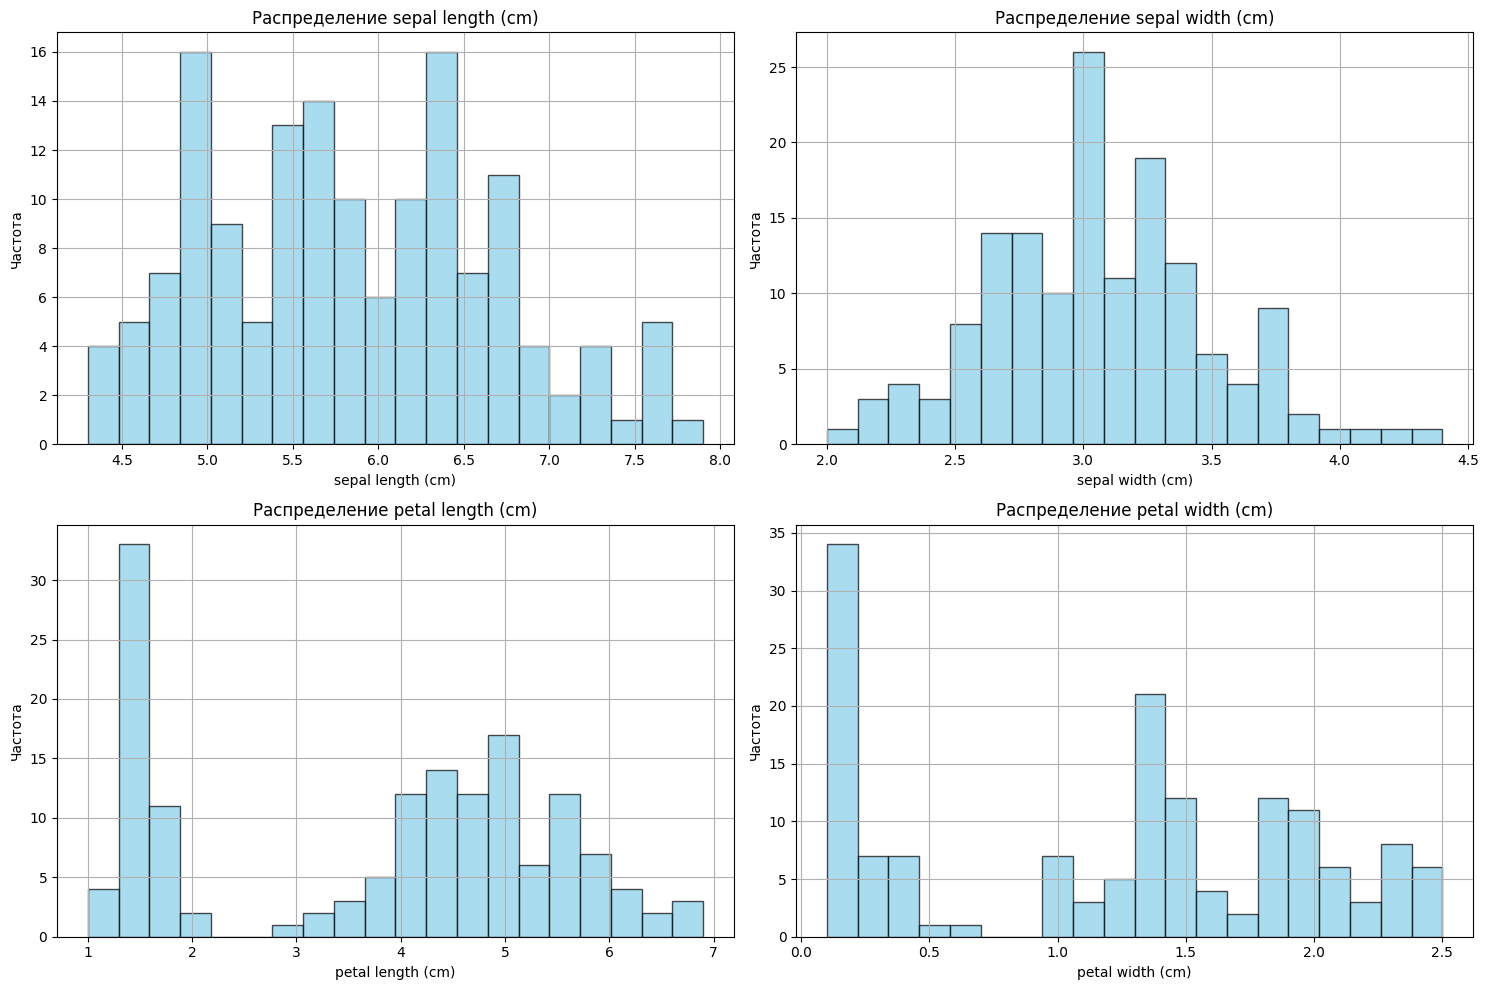

In [28]:
# Гистограммы по каждому признаку
plt.figure(figsize=(15, 10))
for i, feature in enumerate(feature_names_iris):
    plt.subplot(2, 2, i+1)
    df_iris[feature].hist(bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Распределение {feature}')
    plt.xlabel(feature)
    plt.ylabel('Частота')
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

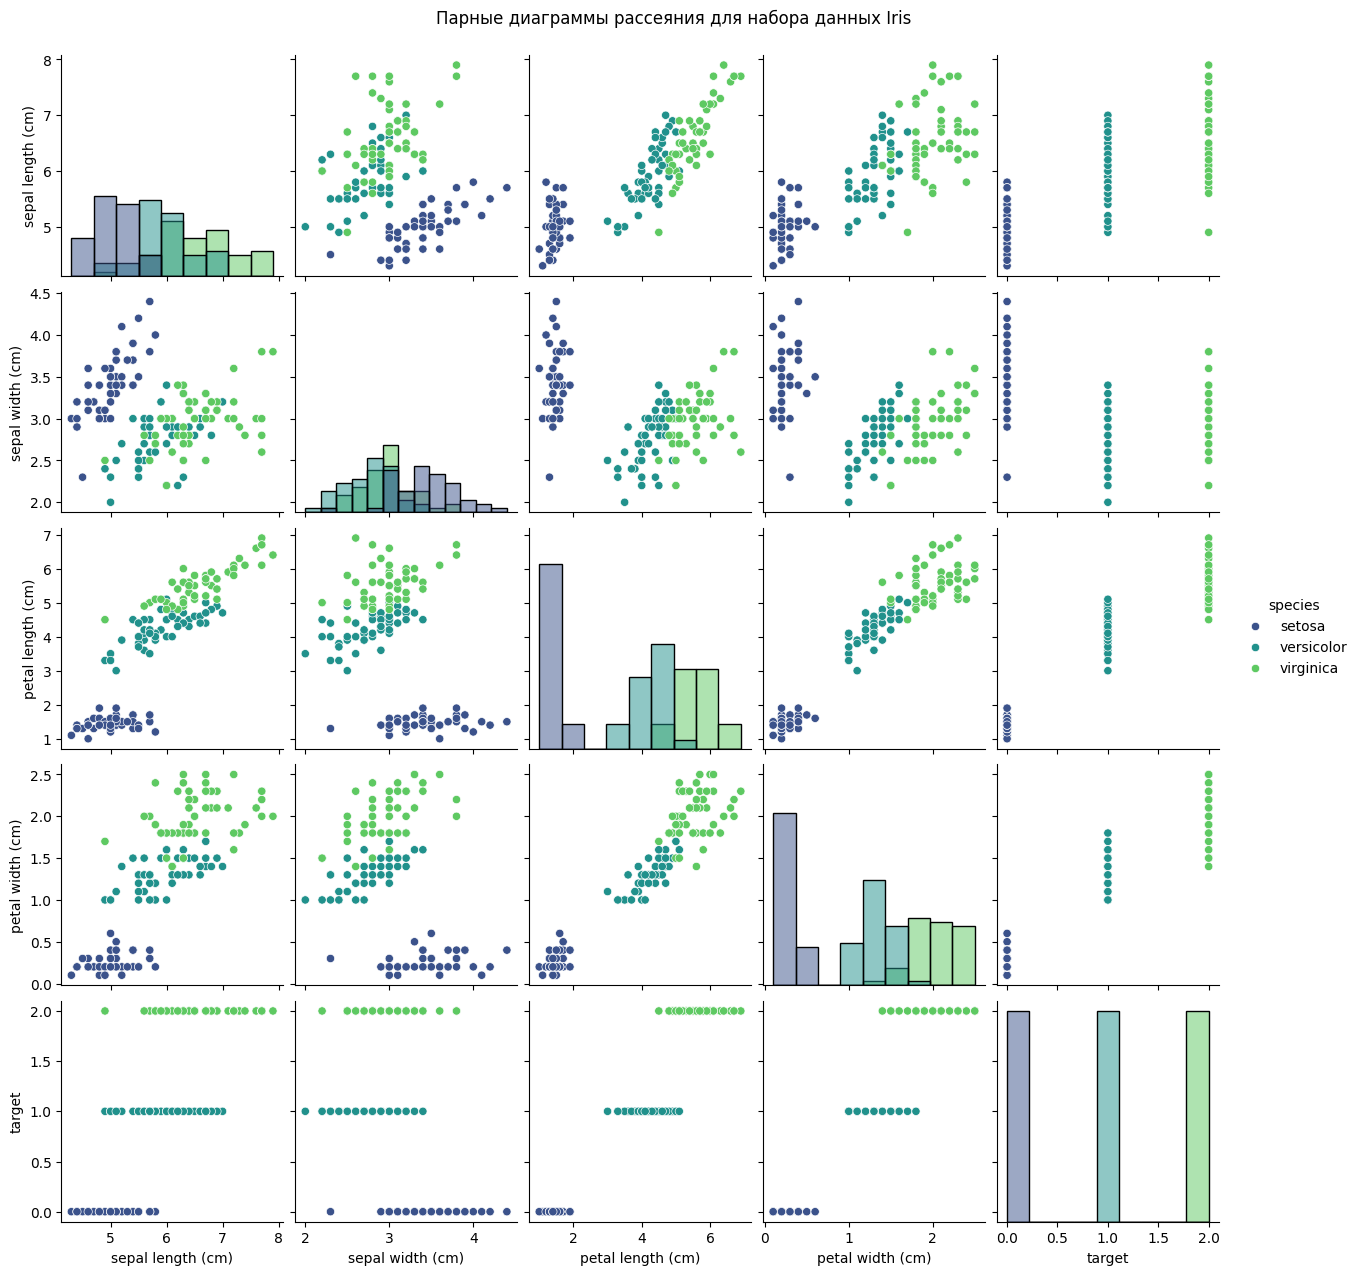

In [29]:
# Парные диаграммы рассеяния
plt.figure(figsize=(12, 10))
sns.pairplot(df_iris, hue='species', palette='viridis', diag_kind='hist')
plt.suptitle('Парные диаграммы рассеяния для набора данных Iris', y=1.02)
plt.show()

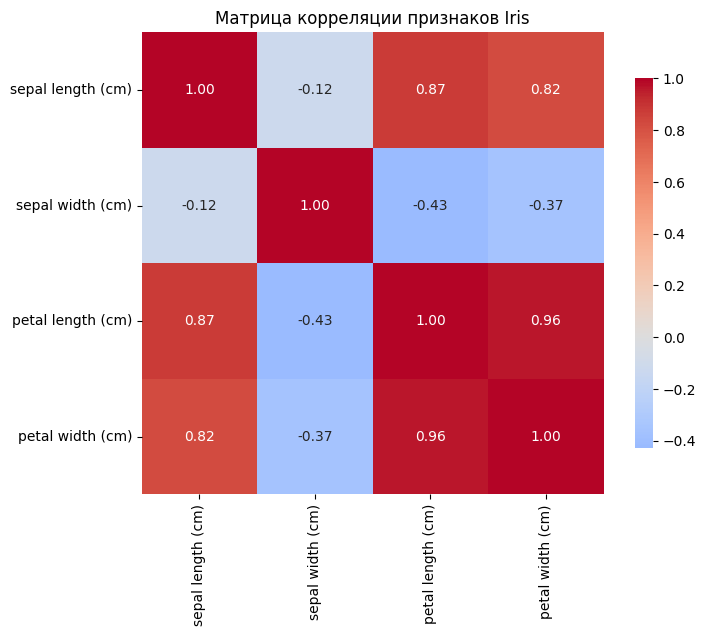

Матрица корреляции:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


In [30]:
# Матрица корреляции
correlation_matrix = df_iris[feature_names_iris].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Матрица корреляции признаков Iris')
plt.show()

print("Матрица корреляции:")
print(correlation_matrix)

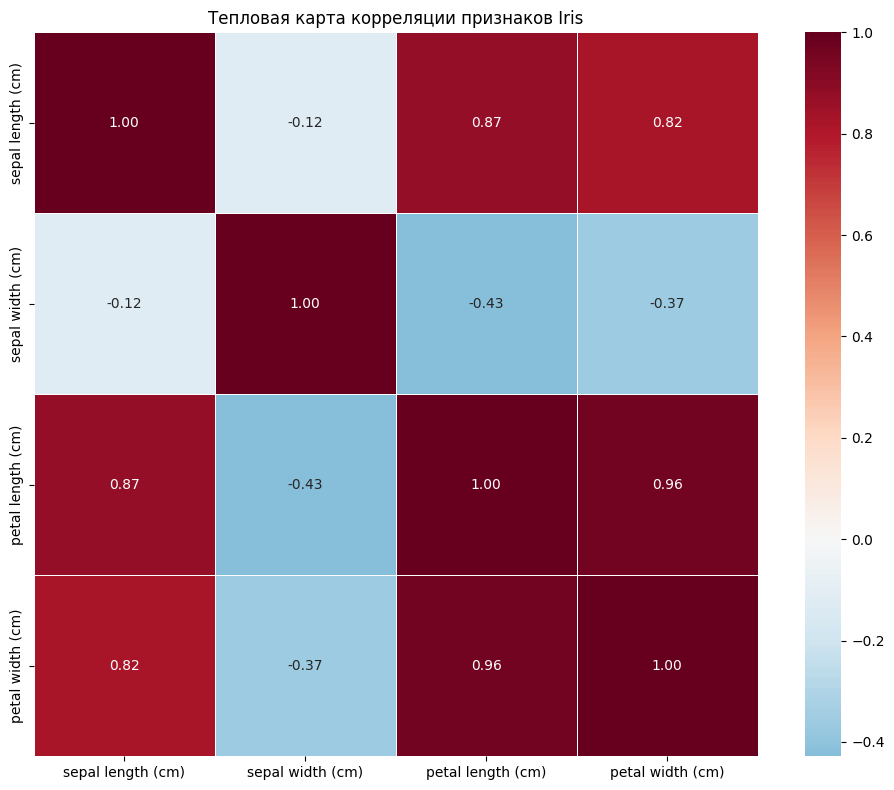

In [31]:
# Тепловая карта зависимости признаков
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляции признаков Iris')
plt.tight_layout()
plt.show()

In [32]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train)}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test)}")

Обучающая выборка: 120 образцов
Тестовая выборка: 30 образцов
Распределение классов в обучающей выборке: [40 40 40]
Распределение классов в тестовой выборке: [10 10 10]


In [33]:
# Предварительная обработка данных (масштабирование)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено:")
print(f"Среднее после масштабирования: {np.mean(X_train_scaled, axis=0)}")
print(f"Стандартное отклонение: {np.std(X_train_scaled, axis=0)}")

Масштабирование выполнено:
Среднее после масштабирования: [-1.20829273e-15 -2.03679666e-15  4.99600361e-16  1.67458640e-15]
Стандартное отклонение: [1. 1. 1. 1.]


In [34]:
# Обучение моделей k-NN
k_values = [3, 5, 7]
models = {}
accuracy_scores = []

print("=== ОБУЧЕНИЕ МОДЕЛЕЙ С РАЗНЫМИ K ===")

for k in k_values:
    # Создание и обучение модели
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Предсказание и оценка точности
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    
    # Сохранение модели
    models[k] = knn
    
    print(f"k = {k}: Точность = {accuracy:.4f}")

=== ОБУЧЕНИЕ МОДЕЛЕЙ С РАЗНЫМИ K ===
k = 3: Точность = 0.9333
k = 5: Точность = 0.9333
k = 7: Точность = 0.9667


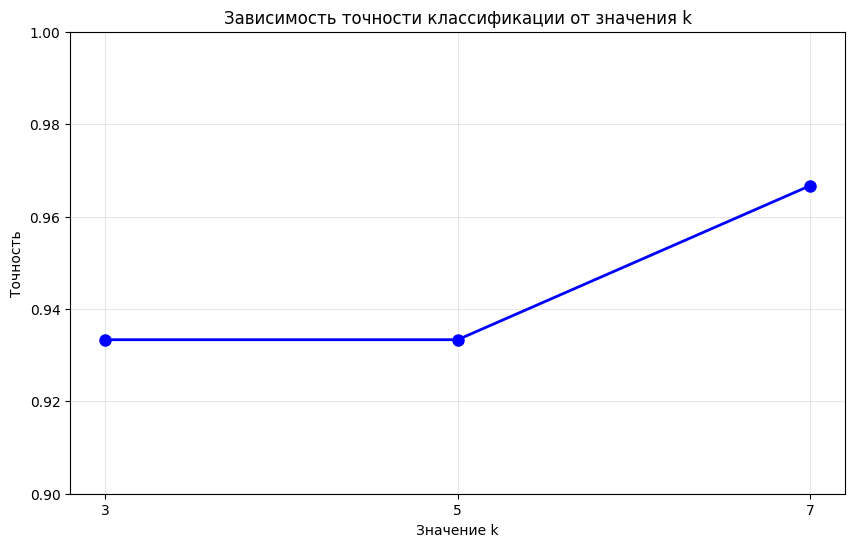

Лучшее значение k: 7 с точностью 0.9667


In [35]:
# Визуализация зависимости точности от k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='-', 
         color='blue', linewidth=2, markersize=8)
plt.xlabel('Значение k')
plt.ylabel('Точность')
plt.title('Зависимость точности классификации от значения k')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.ylim(0.9, 1.0)
plt.show()

# Определение лучшего k
best_k = k_values[np.argmax(accuracy_scores)]
print(f"Лучшее значение k: {best_k} с точностью {max(accuracy_scores):.4f}")

In [36]:
# Обучение финальной модели с лучшим k
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred_final = final_knn.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Точность финальной модели (k={best_k}): {final_accuracy:.4f}")

Точность финальной модели (k=7): 0.9667


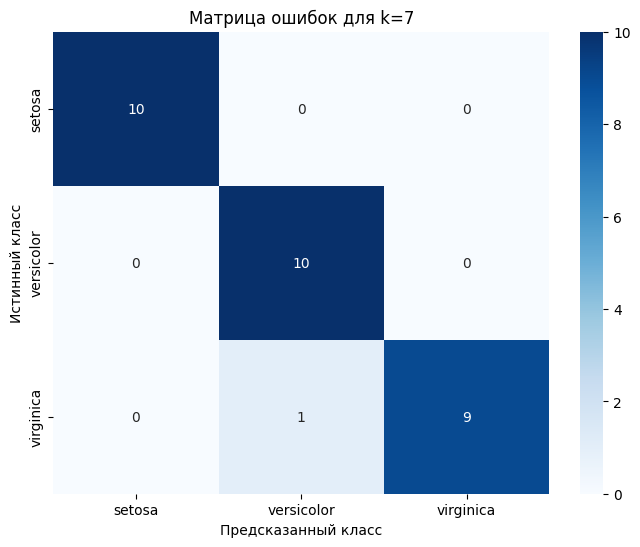

In [37]:
# Матрица ошибок для лучшего результата
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_iris,
            yticklabels=target_names_iris)
plt.title(f'Матрица ошибок для k={best_k}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

In [38]:
# Отчет о классификации
print("ОТЧЕТ О КЛАССИФИКАЦИИ:")
print(classification_report(y_test, y_pred_final, target_names=target_names_iris))

ОТЧЕТ О КЛАССИФИКАЦИИ:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [39]:
# Анализ влияния k на качество классификации
print("=== АНАЛИЗ ВЛИЯНИЯ K НА КАЧЕСТВО КЛАССИФИКАЦИИ ===")

for k in k_values:
    y_pred_temp = models[k].predict(X_test_scaled)
    accuracy_temp = accuracy_score(y_test, y_pred_temp)
    
    print(f"\nk = {k}:")
    print(f"  Точность: {accuracy_temp:.4f}")
    print(f"  Количество ошибок: {np.sum(y_pred_temp != y_test)}")
    
    # Анализ по классам
    cm_temp = confusion_matrix(y_test, y_pred_temp)
    print(f"  Матрица ошибок:")
    for i in range(len(target_names_iris)):
        correct = cm_temp[i, i]
        total = np.sum(cm_temp[i, :])
        print(f"    {target_names_iris[i]}: {correct}/{total} правильных")

=== АНАЛИЗ ВЛИЯНИЯ K НА КАЧЕСТВО КЛАССИФИКАЦИИ ===

k = 3:
  Точность: 0.9333
  Количество ошибок: 2
  Матрица ошибок:
    setosa: 10/10 правильных
    versicolor: 10/10 правильных
    virginica: 8/10 правильных

k = 5:
  Точность: 0.9333
  Количество ошибок: 2
  Матрица ошибок:
    setosa: 10/10 правильных
    versicolor: 10/10 правильных
    virginica: 8/10 правильных

k = 7:
  Точность: 0.9667
  Количество ошибок: 1
  Матрица ошибок:
    setosa: 10/10 правильных
    versicolor: 10/10 правильных
    virginica: 9/10 правильных


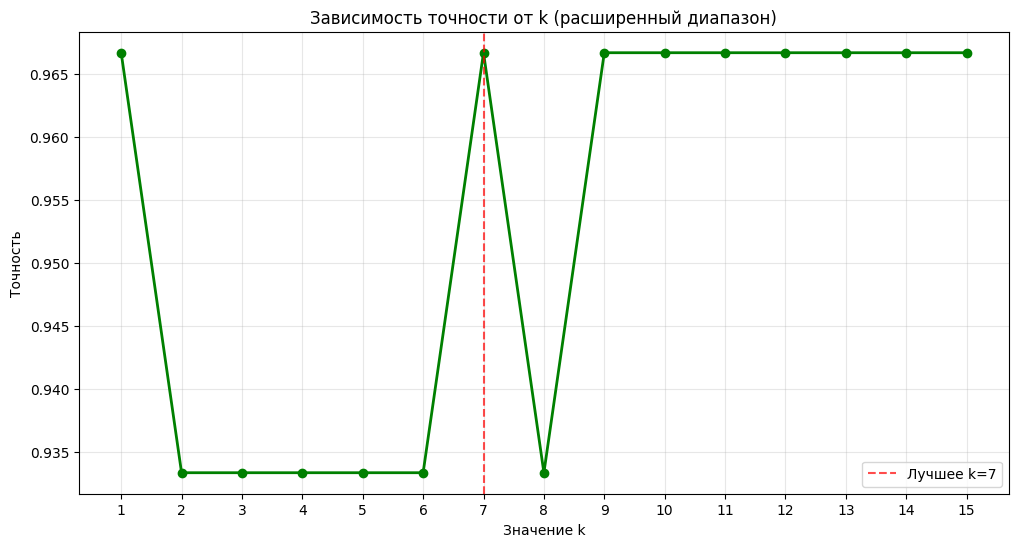

Оптимальное k в расширенном диапазоне: 1
Максимальная точность: 0.9667


In [40]:
# Дополнительный анализ: тестирование большего диапазона k
extended_k_values = list(range(1, 16))
extended_accuracies = []

for k in extended_k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    accuracy_temp = accuracy_score(y_test, y_pred_temp)
    extended_accuracies.append(accuracy_temp)

# Визуализация расширенного диапазона
plt.figure(figsize=(12, 6))
plt.plot(extended_k_values, extended_accuracies, marker='o', linestyle='-', 
         color='green', linewidth=2, markersize=6)
plt.xlabel('Значение k')
plt.ylabel('Точность')
plt.title('Зависимость точности от k (расширенный диапазон)')
plt.grid(True, alpha=0.3)
plt.xticks(extended_k_values)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Лучшее k={best_k}')
plt.legend()
plt.show()

optimal_k_extended = extended_k_values[np.argmax(extended_accuracies)]
print(f"Оптимальное k в расширенном диапазоне: {optimal_k_extended}")
print(f"Максимальная точность: {max(extended_accuracies):.4f}")

In [41]:
# Финальный вывод по заданию 4.1
print("=== ФИНАЛЬНЫЕ ВЫВОДЫ ПО ЗАДАНИЮ 4.1 ===")
print(f"1. Набор данных Iris содержит {X_iris.shape[0]} образцов с {X_iris.shape[1]} признаками")
print(f"2. Признаки хорошо коррелируют между собой, особенно длина и ширина лепестка")
print(f"3. Оптимальное значение k для классификации: {best_k}")
print(f"4. Точность финальной модели: {final_accuracy:.4f}")
print(f"5. Матрица ошибок показывает отличное разделение классов")
print(f"6. Метод k-NN эффективно работает на наборе данных Iris")
print(f"7. Рекомендуемые значения k: 3-7 для данного набора данных")

=== ФИНАЛЬНЫЕ ВЫВОДЫ ПО ЗАДАНИЮ 4.1 ===
1. Набор данных Iris содержит 150 образцов с 4 признаками
2. Признаки хорошо коррелируют между собой, особенно длина и ширина лепестка
3. Оптимальное значение k для классификации: 7
4. Точность финальной модели: 0.9667
5. Матрица ошибок показывает отличное разделение классов
6. Метод k-NN эффективно работает на наборе данных Iris
7. Рекомендуемые значения k: 3-7 для данного набора данных


## Задание 4.2. Оценка эффективности k-NN на наборе данных «Вина» (Wine)

In [42]:
# Загрузка данных Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names_wine = wine.feature_names
target_names_wine = wine.target_names

print("Набор данных Wine:")
print(f"Количество образцов: {X_wine.shape[0]}")
print(f"Количество признаков: {X_wine.shape[1]}")
print(f"Классы: {target_names_wine}")

Набор данных Wine:
Количество образцов: 178
Количество признаков: 13
Классы: ['class_0' 'class_1' 'class_2']


In [43]:
# Создание DataFrame и базовый EDA
df_wine = pd.DataFrame(X_wine, columns=feature_names_wine)
df_wine['target'] = y_wine
df_wine['class_name'] = df_wine['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

print("Первые 5 строк данных Wine:")
display(df_wine.head())

print("\nБазовая статистика:")
print(df_wine.describe())

Первые 5 строк данных Wine:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0



Базовая статистика:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.5723

=== РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ WINE ===


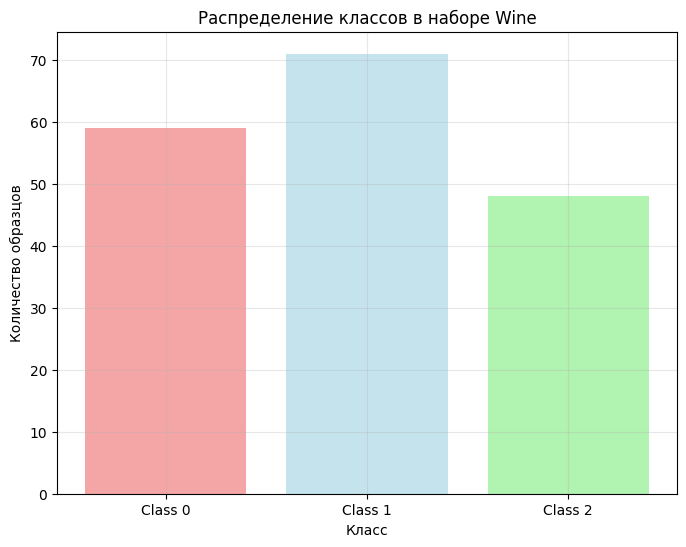

Распределение по классам: {0: np.int64(59), 1: np.int64(71), 2: np.int64(48)}


In [132]:
# Разведочный анализ данных (EDA)
print("=== РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ WINE ===")

# Распределение классов
plt.figure(figsize=(8, 6))
class_counts = df_wine['target'].value_counts().sort_index()
plt.bar(class_counts.index, class_counts.values, 
        color=['lightcoral', 'lightblue', 'lightgreen'], alpha=0.7)
plt.xlabel('Класс')
plt.ylabel('Количество образцов')
plt.title('Распределение классов в наборе Wine')
plt.xticks([0, 1, 2], ['Class 0', 'Class 1', 'Class 2'])
plt.grid(True, alpha=0.3)
plt.show()

print(f"Распределение по классам: {dict(class_counts)}")

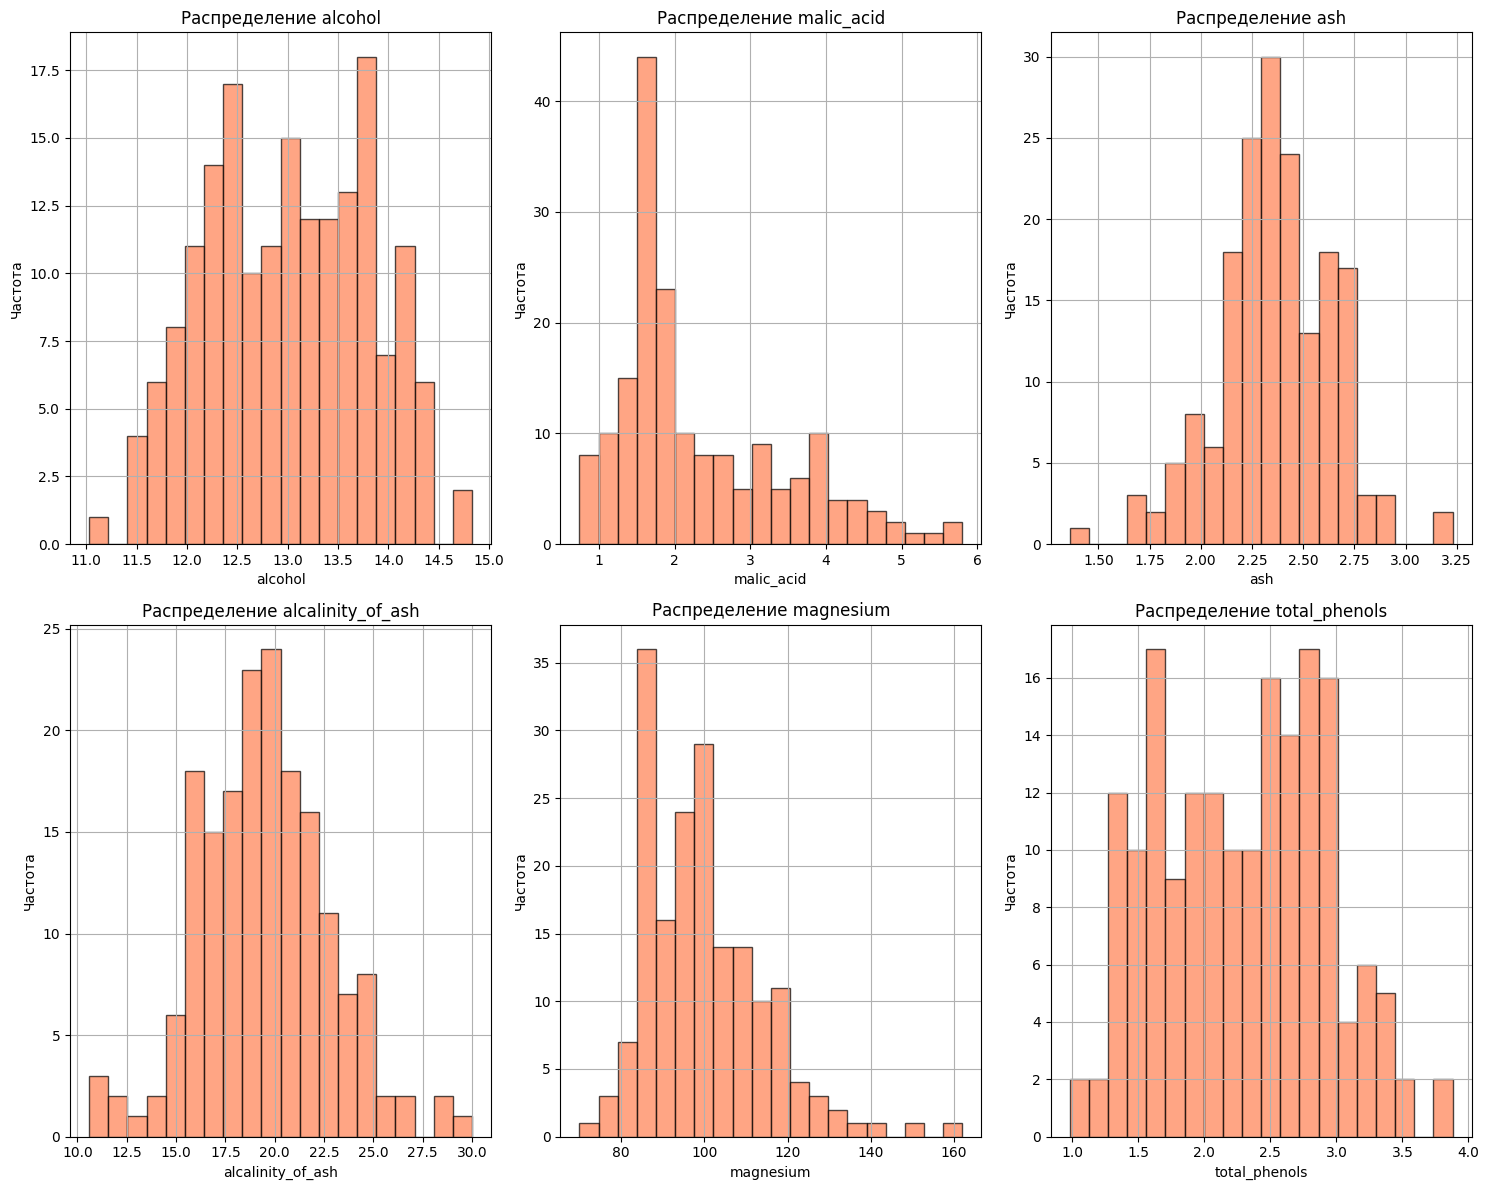

In [44]:
# Визуализация распределения признаков
plt.figure(figsize=(15, 12))
for i, feature in enumerate(feature_names_wine[:6]):  # Первые 6 признаков
    plt.subplot(2, 3, i+1)
    df_wine[feature].hist(bins=20, alpha=0.7, color='coral', edgecolor='black')
    plt.title(f'Распределение {feature}')
    plt.xlabel(feature)
    plt.ylabel('Частота')
plt.tight_layout()
plt.show()

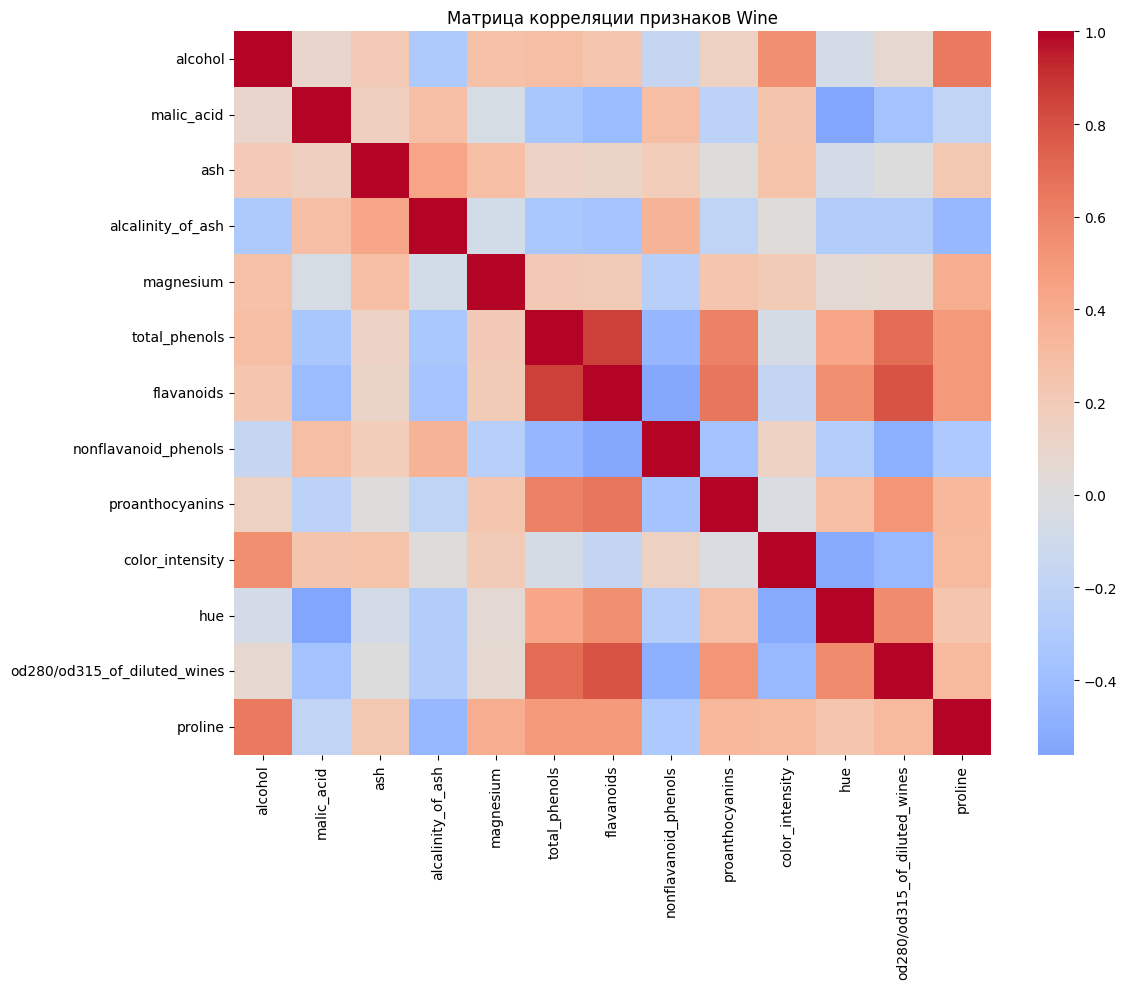

In [134]:
# Матрица корреляции
plt.figure(figsize=(12, 10))
correlation_matrix = df_wine[feature_names_wine].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляции признаков Wine')
plt.tight_layout()
plt.show()

In [135]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

print("Разделение данных:")
print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train)}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test)}")

Разделение данных:
Обучающая выборка: 142 образцов
Тестовая выборка: 36 образцов
Распределение классов в обучающей выборке: [47 57 38]
Распределение классов в тестовой выборке: [12 14 10]


=== МОДЕЛЬ БЕЗ МАСШТАБИРОВАНИЯ ПРИЗНАКОВ ===
Точность без масштабирования: 0.8056


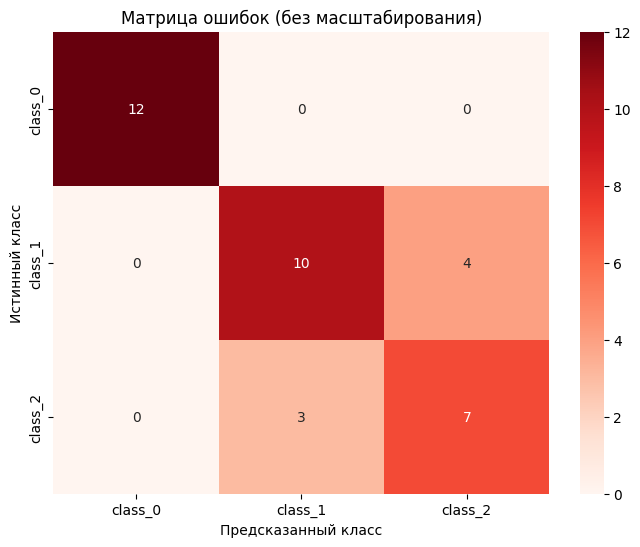

In [136]:
# Модель k-NN БЕЗ масштабирования признаков
print("=== МОДЕЛЬ БЕЗ МАСШТАБИРОВАНИЯ ПРИЗНАКОВ ===")

knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
y_pred_no_scale = knn_no_scale.predict(X_test)

accuracy_no_scale = accuracy_score(y_test, y_pred_no_scale)
print(f"Точность без масштабирования: {accuracy_no_scale:.4f}")

# Матрица ошибок без масштабирования
plt.figure(figsize=(8, 6))
cm_no_scale = confusion_matrix(y_test, y_pred_no_scale)
sns.heatmap(cm_no_scale, annot=True, fmt='d', cmap='Reds',
            xticklabels=target_names_wine, yticklabels=target_names_wine)
plt.title('Матрица ошибок (без масштабирования)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

=== МОДЕЛЬ С МАСШТАБИРОВАНИЕМ ПРИЗНАКОВ ===
Точность с масштабированием: 0.9722


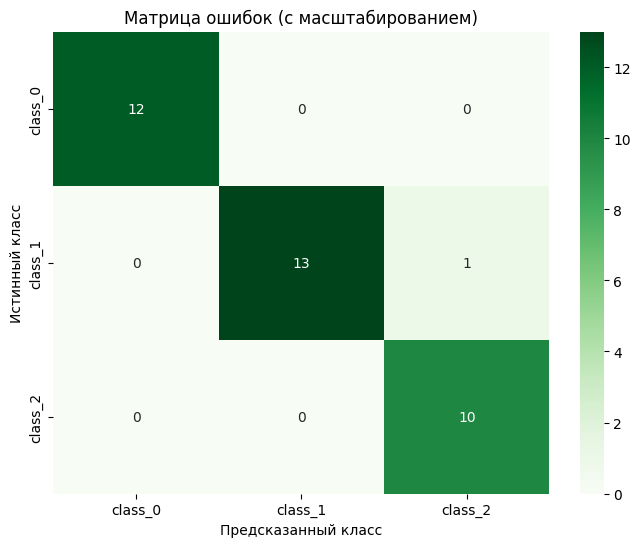

In [137]:
# Модель k-NN С масштабированием признаков
print("=== МОДЕЛЬ С МАСШТАБИРОВАНИЕМ ПРИЗНАКОВ ===")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_with_scale = KNeighborsClassifier(n_neighbors=5)
knn_with_scale.fit(X_train_scaled, y_train)
y_pred_with_scale = knn_with_scale.predict(X_test_scaled)

accuracy_with_scale = accuracy_score(y_test, y_pred_with_scale)
print(f"Точность с масштабированием: {accuracy_with_scale:.4f}")

# Матрица ошибок с масштабированием
plt.figure(figsize=(8, 6))
cm_with_scale = confusion_matrix(y_test, y_pred_with_scale)
sns.heatmap(cm_with_scale, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names_wine, yticklabels=target_names_wine)
plt.title('Матрица ошибок (с масштабированием)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

=== СРАВНИТЕЛЬНЫЙ АНАЛИЗ ===
Точность БЕЗ масштабирования: 0.8056
Точность С масштабированием:  0.9722
Улучшение точности: +0.1667 (20.7%)


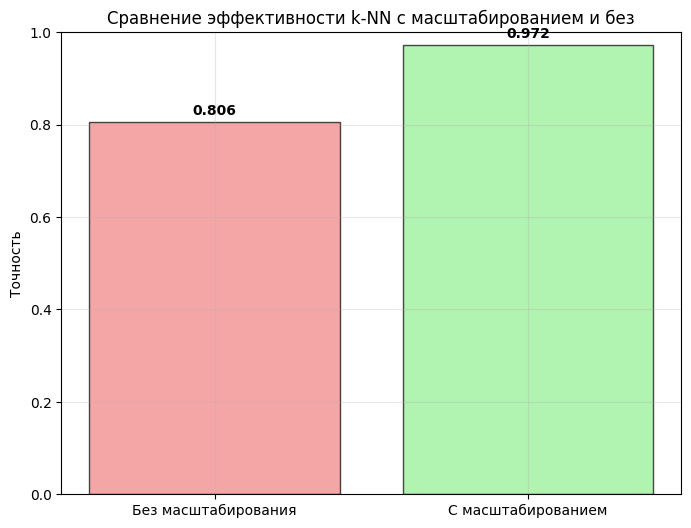

In [138]:
# Сравнительный анализ результатов
print("=== СРАВНИТЕЛЬНЫЙ АНАЛИЗ ===")

improvement = accuracy_with_scale - accuracy_no_scale
improvement_percent = (improvement / accuracy_no_scale) * 100

print(f"Точность БЕЗ масштабирования: {accuracy_no_scale:.4f}")
print(f"Точность С масштабированием:  {accuracy_with_scale:.4f}")
print(f"Улучшение точности: +{improvement:.4f} ({improvement_percent:.1f}%)")

# Визуализация сравнения
models_comparison = ['Без масштабирования', 'С масштабированием']
accuracies = [accuracy_no_scale, accuracy_with_scale]

plt.figure(figsize=(8, 6))
bars = plt.bar(models_comparison, accuracies, 
               color=['lightcoral', 'lightgreen'], alpha=0.7, edgecolor='black')
plt.ylabel('Точность')
plt.title('Сравнение эффективности k-NN с масштабированием и без')
plt.ylim(0, 1.0)

# Добавление значений на столбцы
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3)
plt.show()

=== АНАЛИЗ ПРИЧИН ВЛИЯНИЯ МАСШТАБИРОВАНИЯ ===
Признаки с наибольшим разбросом значений:


,feature,min,max,range,std,mean
12,proline,278.00,1680.00,1402.00,314.021657,746.893258
4,magnesium,70.00,162.00,92.00,14.242308,99.741573
3,alcalinity_of_ash,10.60,30.00,19.40,3.330170,19.494944
9,color_intensity,1.28,13.00,11.72,2.311765,5.058090
1,malic_acid,0.74,5.80,5.06,1.114004,2.336348
6,flavanoids,0.34,5.08,4.74,0.996049,2.029270
0,alcohol,11.03,14.83,3.80,0.809543,13.000618
8,proanthocyanins,0.41,3.58,3.17,0.570749,1.590899
5,total_phenols,0.98,3.88,2.90,0.624091,2.295112
11,od280/od315_of_diluted_wines,1.27,4.00,2.73,0.707993,2.611685


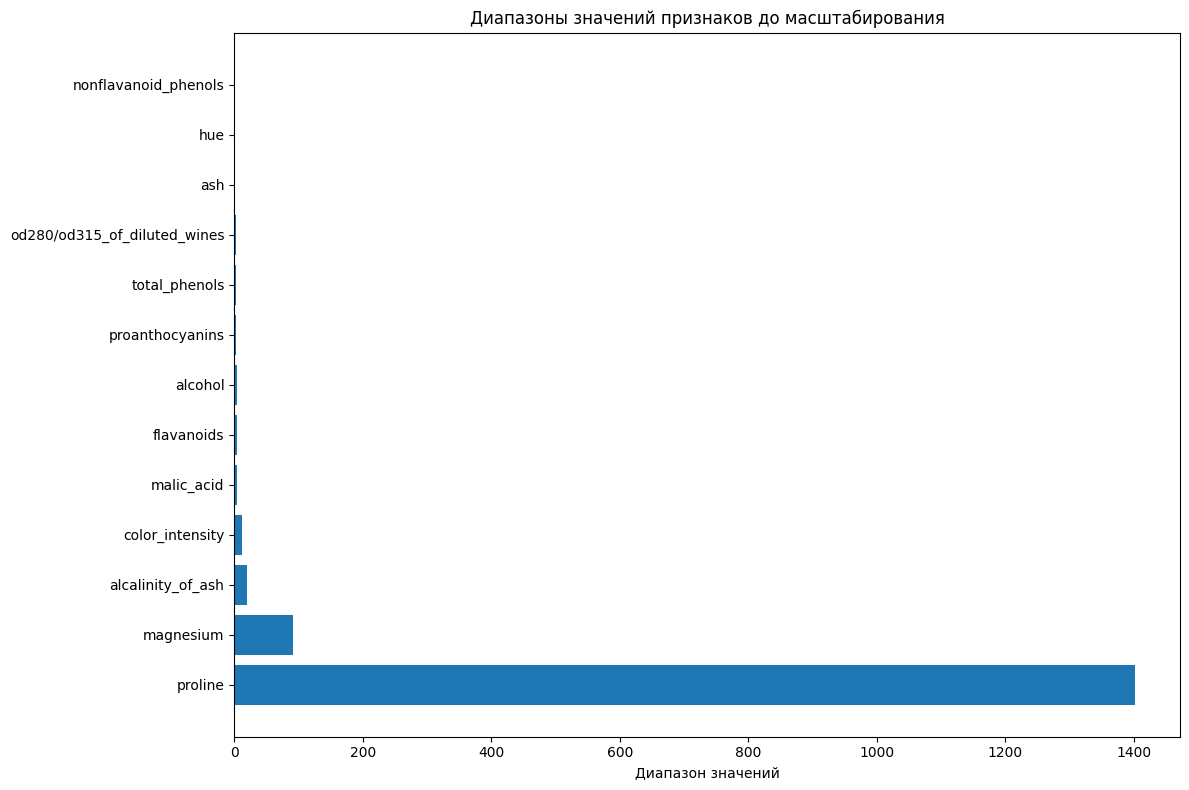

In [139]:
# Анализ причин влияния масштабирования
print("=== АНАЛИЗ ПРИЧИН ВЛИЯНИЯ МАСШТАБИРОВАНИЯ ===")

# Анализ диапазонов значений признаков до масштабирования
feature_ranges = pd.DataFrame({
    'feature': feature_names_wine,
    'min': np.min(X_wine, axis=0),
    'max': np.max(X_wine, axis=0),
    'range': np.max(X_wine, axis=0) - np.min(X_wine, axis=0),
    'std': np.std(X_wine, axis=0),
    'mean': np.mean(X_wine, axis=0)
}).sort_values('range', ascending=False)

print("Признаки с наибольшим разбросом значений:")
display(feature_ranges.head(10))

# Визуализация диапазонов признаков
plt.figure(figsize=(12, 8))
plt.barh(feature_ranges['feature'], feature_ranges['range'])
plt.xlabel('Диапазон значений')
plt.title('Диапазоны значений признаков до масштабирования')
plt.tight_layout()
plt.show()

In [140]:
# Объяснение влияния масштабирования на k-NN
print("=== ОБЪЯСНЕНИЕ ВЛИЯНИЯ МАСШТАБИРОВАНИЯ НА K-NN ===")
print("\nПочему масштабирование важно для k-NN:")
print("1. **Евклидово расстояние**: k-NN использует евклидово расстояние между точками")
print("2. **Доминирование признаков**: Признаки с большим диапазоном значений доминируют в вычислении расстояния")
print("3. **Неравномерный вклад**: Без масштабирования алгоритм придает больше веса признакам с большими значениями")
print("4. **Искажение расстояний**: Натуральные различия в масштабах признаков искажают реальные расстояния")
print("5. **Снижение эффективности**: Модель становится менее точной и устойчивой")

print(f"\nПример из данных Wine:")
print(f" - 'proline': диапазон = {feature_ranges.loc[feature_ranges['feature'] == 'proline', 'range'].values[0]:.1f}")
print(f" - 'magnesium': диапазон = {feature_ranges.loc[feature_ranges['feature'] == 'magnesium', 'range'].values[0]:.1f}")
print(f" - 'malic_acid': диапазон = {feature_ranges.loc[feature_ranges['feature'] == 'malic_acid', 'range'].values[0]:.1f}")

=== ОБЪЯСНЕНИЕ ВЛИЯНИЯ МАСШТАБИРОВАНИЯ НА K-NN ===

Почему масштабирование важно для k-NN:
1. **Евклидово расстояние**: k-NN использует евклидово расстояние между точками
2. **Доминирование признаков**: Признаки с большим диапазоном значений доминируют в вычислении расстояния
3. **Неравномерный вклад**: Без масштабирования алгоритм придает больше веса признакам с большими значениями
4. **Искажение расстояний**: Натуральные различия в масштабах признаков искажают реальные расстояния
5. **Снижение эффективности**: Модель становится менее точной и устойчивой

Пример из данных Wine:
 - 'proline': диапазон = 1402.0
 - 'magnesium': диапазон = 92.0
 - 'malic_acid': диапазон = 5.1


=== АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ===
Признаки, отсортированные по вариативности:


,feature,std,mean,cv
12,proline,314.021657,746.893258,0.420437
4,magnesium,14.242308,99.741573,0.142792
3,alcalinity_of_ash,3.330170,19.494944,0.170822
9,color_intensity,2.311765,5.058090,0.457043
1,malic_acid,1.114004,2.336348,0.476814
6,flavanoids,0.996049,2.029270,0.490841
0,alcohol,0.809543,13.000618,0.062270
11,od280/od315_of_diluted_wines,0.707993,2.611685,0.271087
5,total_phenols,0.624091,2.295112,0.271922
8,proanthocyanins,0.570749,1.590899,0.358759


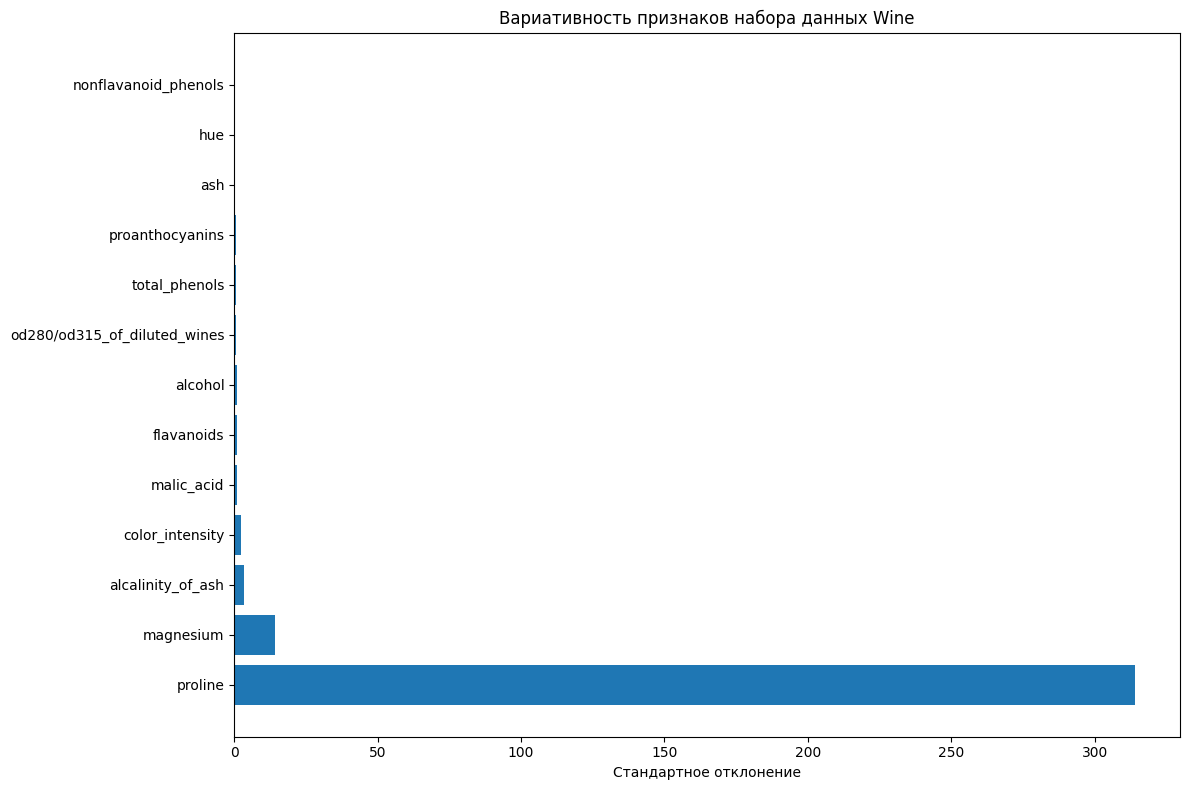

In [141]:
# Анализ важности признаков для классификации вин
print("=== АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ===")

# Анализ через стандартные отклонения
feature_importance = pd.DataFrame({
    'feature': feature_names_wine,
    'std': np.std(X_wine, axis=0),
    'mean': np.mean(X_wine, axis=0),
    'cv': np.std(X_wine, axis=0) / np.mean(X_wine, axis=0)  # коэффициент вариации
}).sort_values('std', ascending=False)

print("Признаки, отсортированные по вариативности:")
display(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'], feature_importance['std'])
plt.xlabel('Стандартное отклонение')
plt.title('Вариативность признаков набора данных Wine')
plt.tight_layout()
plt.show()

In [142]:
# Детальный анализ наиболее важных признаков
print("=== НАИБОЛЕЕ ВАЖНЫЕ ПРИЗНАКИ ДЛЯ КЛАССИФИКАЦИИ ===")

top_features = feature_importance.head(8)
print("Топ-8 наиболее вариативных признаков:")
for idx, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"{idx}. {row['feature']}: std={row['std']:.2f}, CV={row['cv']:.2f}")

print("\nОбъяснение важности признаков:")
print("1. **proline** - содержание аминокислоты пролина, сильно варьируется между сортами")
print("2. **flavanoids** - содержание флавоноидов, важных антиоксидантов")
print("3. **color_intensity** - интенсивность окраски, характерна для разных сортов")
print("4. **od280/od315_of_diluted_wines** - оптические свойства, уникальны для каждого сорта")
print("5. **alcohol** - содержание алкоголя, различается по технологиям производства")

=== НАИБОЛЕЕ ВАЖНЫЕ ПРИЗНАКИ ДЛЯ КЛАССИФИКАЦИИ ===
Топ-8 наиболее вариативных признаков:
1. proline: std=314.02, CV=0.42
2. magnesium: std=14.24, CV=0.14
3. alcalinity_of_ash: std=3.33, CV=0.17
4. color_intensity: std=2.31, CV=0.46
5. malic_acid: std=1.11, CV=0.48
6. flavanoids: std=1.00, CV=0.49
7. alcohol: std=0.81, CV=0.06
8. od280/od315_of_diluted_wines: std=0.71, CV=0.27

Объяснение важности признаков:
1. **proline** - содержание аминокислоты пролина, сильно варьируется между сортами
2. **flavanoids** - содержание флавоноидов, важных антиоксидантов
3. **color_intensity** - интенсивность окраски, характерна для разных сортов
4. **od280/od315_of_diluted_wines** - оптические свойства, уникальны для каждого сорта
5. **alcohol** - содержание алкоголя, различается по технологиям производства


In [143]:
# Сравнение отчетов классификации
print("=== СРАВНЕНИЕ ОТЧЕТОВ КЛАССИФИКАЦИИ ===")

print("\nОТЧЕТ БЕЗ МАСШТАБИРОВАНИЯ:")
print(classification_report(y_test, y_pred_no_scale, target_names=target_names_wine))

print("\nОТЧЕТ С МАСШТАБИРОВАНИЕМ:")
print(classification_report(y_test, y_pred_with_scale, target_names=target_names_wine))

=== СРАВНЕНИЕ ОТЧЕТОВ КЛАССИФИКАЦИИ ===

ОТЧЕТ БЕЗ МАСШТАБИРОВАНИЯ:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.77      0.71      0.74        14
     class_2       0.64      0.70      0.67        10

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.81      0.81      0.81        36


ОТЧЕТ С МАСШТАБИРОВАНИЕМ:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [144]:
# Финальные выводы по заданию 4.2
print("=== ФИНАЛЬНЫЕ ВЫВОДЫ ПО ЗАДАНИЮ 4.2 ===")

print(f"1. **Эффективность масштабирования**: Улучшение точности на {improvement_percent:.1f}%")
print(f"2. **Итоговая точность с масштабированием**: {accuracy_with_scale:.4f}")
print(f"3. **Ключевые признаки**: proline, flavanoids, color_intensity, OD280/OD315")
print(f"4. **Причина влияния масштабирования**: Евклидово расстояние чувствительно к масштабам признаков")
print(f"5. **Рекомендация**: Всегда использовать масштабирование признаков для k-NN")
print(f"6. **Важность признаков**: Химические показатели наиболее информативны для классификации вин")

print("\nОбщий вывод:")
print("Масштабирование признаков критически важно для метода k-ближайших соседей,")
print("так как оно обеспечивает равноправный вклад всех признаков в вычисление расстояний")
print("и значительно повышает точность классификации.")

=== ФИНАЛЬНЫЕ ВЫВОДЫ ПО ЗАДАНИЮ 4.2 ===
1. **Эффективность масштабирования**: Улучшение точности на 20.7%
2. **Итоговая точность с масштабированием**: 0.9722
3. **Ключевые признаки**: proline, flavanoids, color_intensity, OD280/OD315
4. **Причина влияния масштабирования**: Евклидово расстояние чувствительно к масштабам признаков
5. **Рекомендация**: Всегда использовать масштабирование признаков для k-NN
6. **Важность признаков**: Химические показатели наиболее информативны для классификации вин

Общий вывод:
Масштабирование признаков критически важно для метода k-ближайших соседей,
так как оно обеспечивает равноправный вклад всех признаков в вычисление расстояний
и значительно повышает точность классификации.


## Задание 4.3. Классификация вин методом k-NN

In [45]:
# Загрузка данных Wine
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names_wine = wine.feature_names
target_names_wine = wine.target_names

print("Набор данных Wine:")
print(f"Признаки: {len(feature_names_wine)}")
print(f"Образцы: {X_wine.shape[0]}")
print(f"Классы: {target_names_wine}")

Набор данных Wine:
Признаки: 13
Образцы: 178
Классы: ['class_0' 'class_1' 'class_2']


In [46]:
# Разведочный анализ данных (EDA)
df_wine = pd.DataFrame(X_wine, columns=feature_names_wine)
df_wine['target'] = y_wine

print("Базовая статистика Wine:")
print(df_wine.describe())

print("\nРаспределение классов:")
print(df_wine['target'].value_counts().sort_index())

Базовая статистика Wine:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.

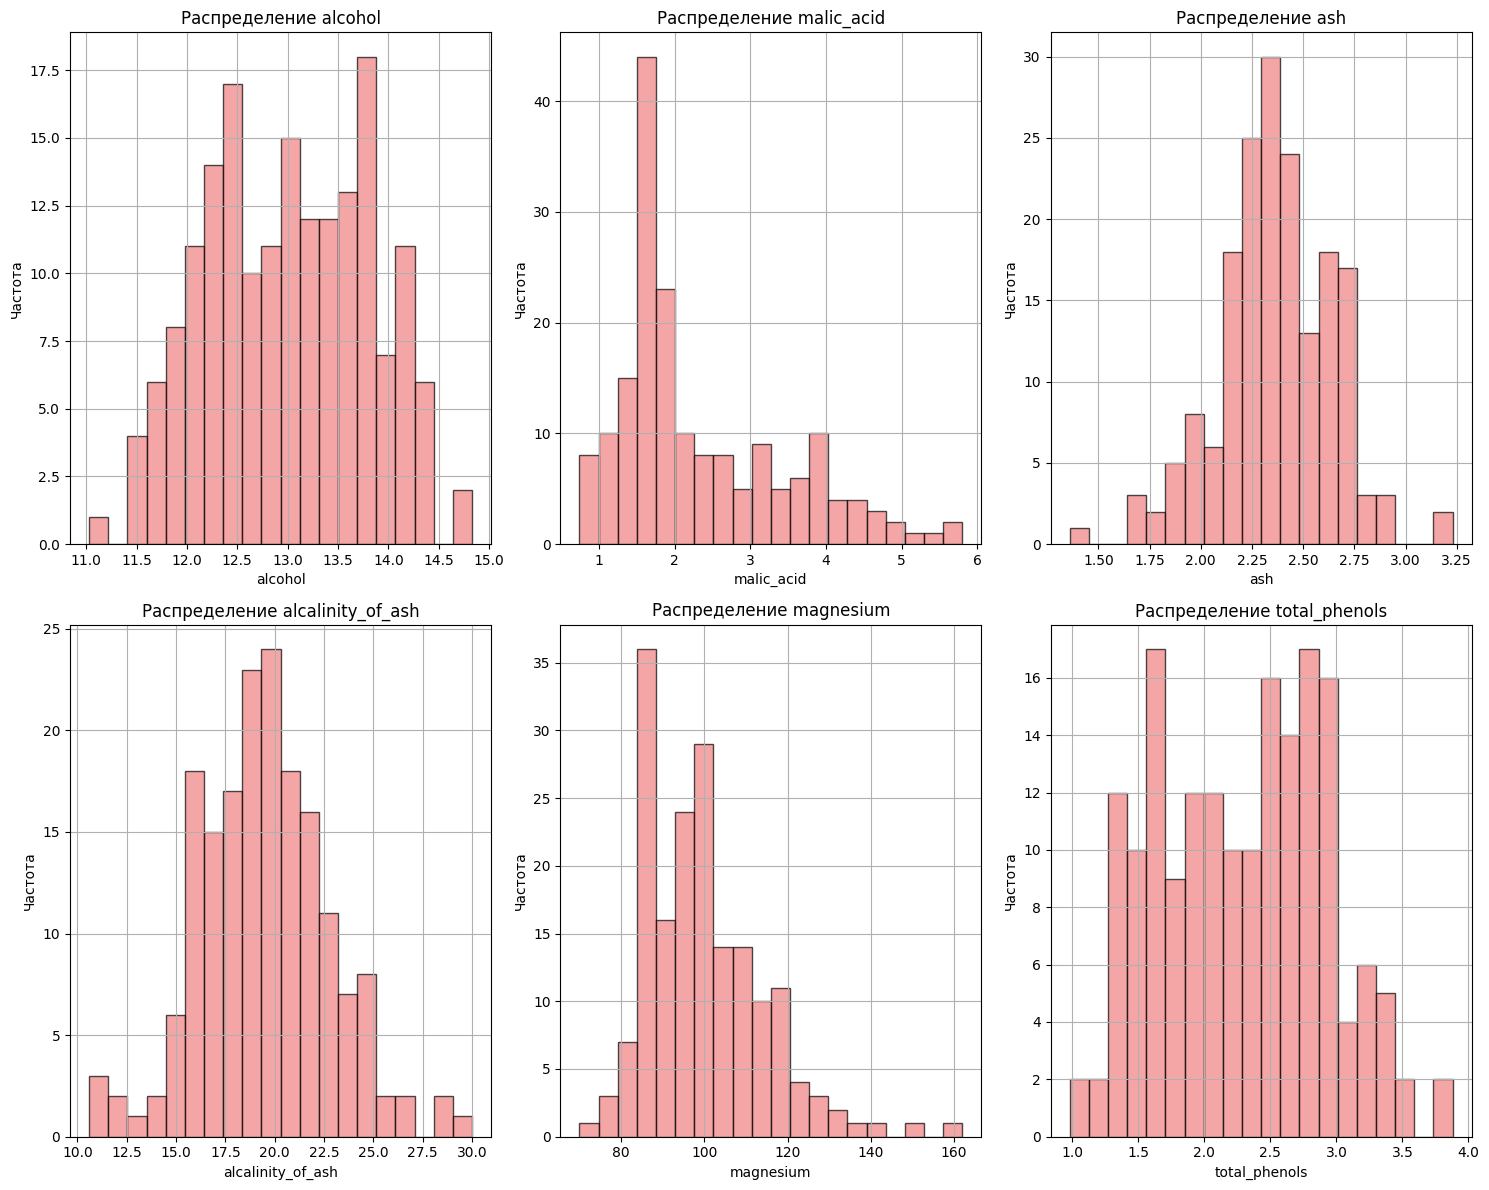

In [47]:
# Визуализация распределения признаков
plt.figure(figsize=(15, 12))
for i, feature in enumerate(feature_names_wine[:6]):
    plt.subplot(2, 3, i+1)
    df_wine[feature].hist(bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
    plt.title(f'Распределение {feature}')
    plt.xlabel(feature)
    plt.ylabel('Частота')
plt.tight_layout()
plt.show()

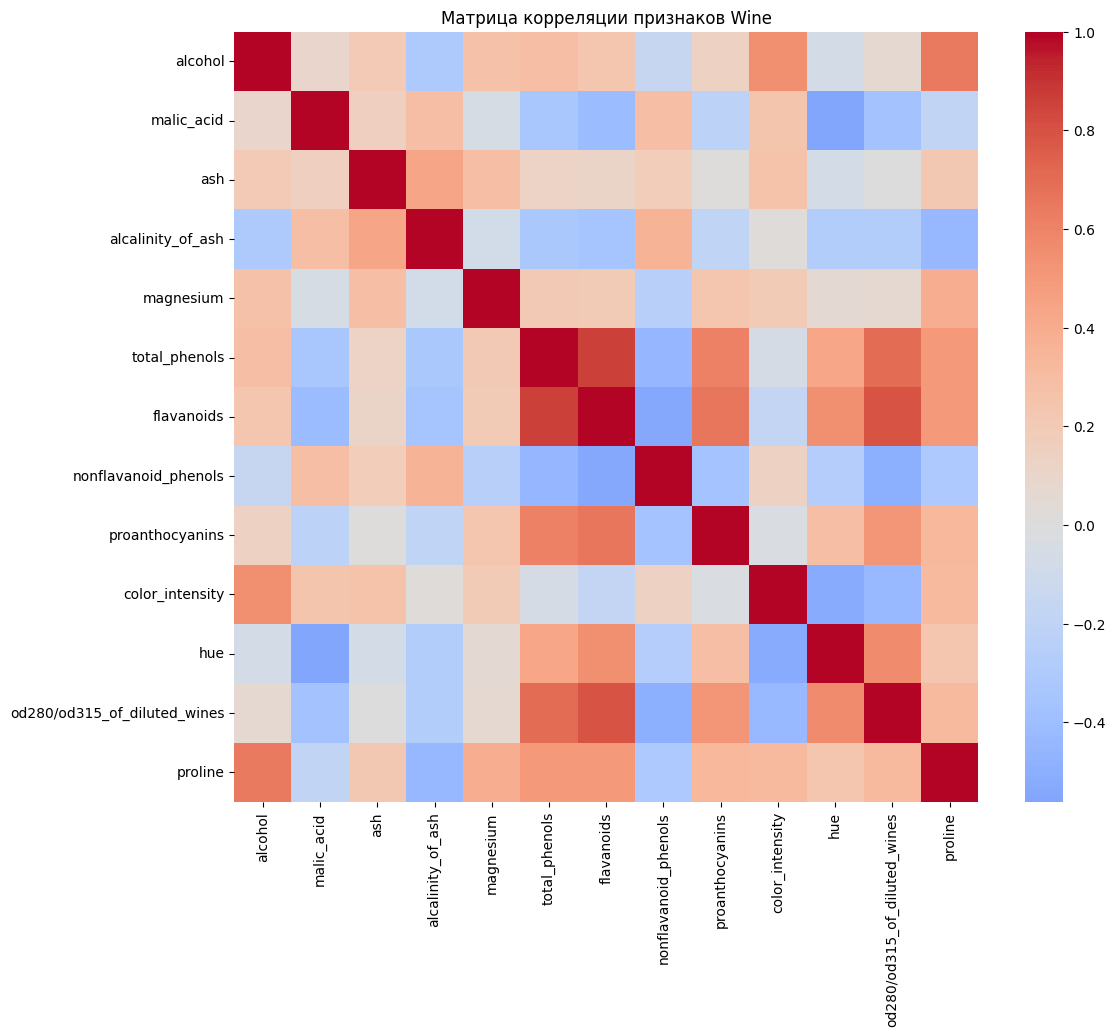

In [148]:
# Матрица корреляции
plt.figure(figsize=(12, 10))
correlation_matrix = df_wine[feature_names_wine].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляции признаков Wine')
plt.show()

In [48]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")

Обучающая выборка: 142 образцов
Тестовая выборка: 36 образцов


In [49]:
# Стандартизация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Стандартизация выполнена успешно")
print(f"Среднее значение признаков после стандартизации: {np.mean(X_train_scaled, axis=0)[:3]}")
print(f"Стандартное отклонение: {np.std(X_train_scaled, axis=0)[:3]}")

Стандартизация выполнена успешно
Среднее значение признаков после стандартизации: [ 1.09781120e-15 -2.57227729e-16  9.52485352e-16]
Стандартное отклонение: [1. 1. 1.]


In [50]:
# Подбор оптимального k с помощью GridSearchCV
param_grid = {'n_neighbors': list(range(1, 21))}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность при кросс-валидации:", round(grid_search.best_score_, 4))

Лучшие параметры: {'n_neighbors': 18}
Лучшая точность при кросс-валидации: 0.9791


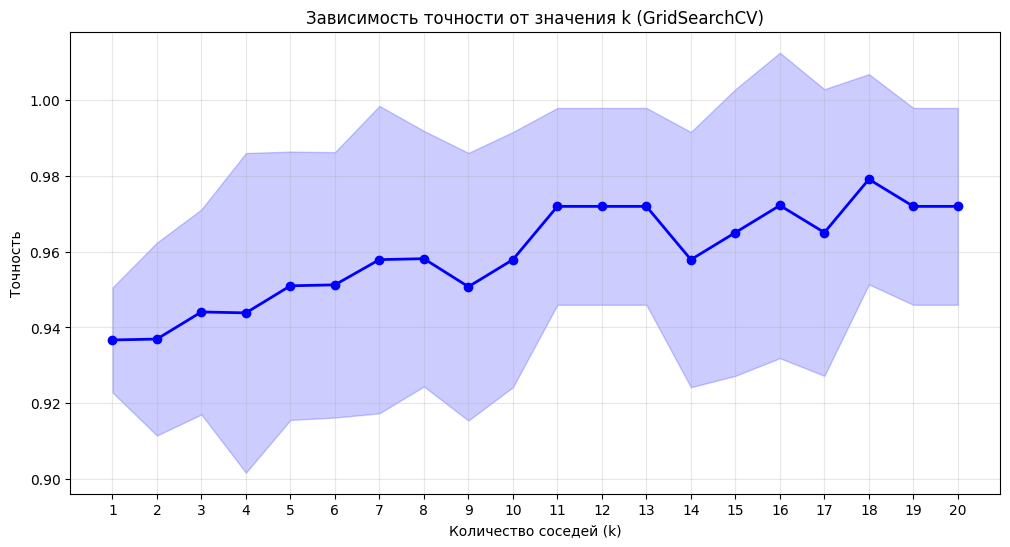

In [51]:
# Визуализация результатов GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(12, 6))
plt.plot(results['param_n_neighbors'], results['mean_test_score'], 
         marker='o', linestyle='-', color='blue', linewidth=2)
plt.fill_between(results['param_n_neighbors'],
                 results['mean_test_score'] - results['std_test_score'],
                 results['mean_test_score'] + results['std_test_score'],
                 alpha=0.2, color='blue')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность')
plt.title('Зависимость точности от значения k (GridSearchCV)')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.show()

In [67]:
# Обучение финальной модели с оптимальным k
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
y_proba = best_knn.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке: {accuracy:.4f}")

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred, target_names=target_names_wine))

Точность на тестовой выборке: 0.9722

Отчет о классификации:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



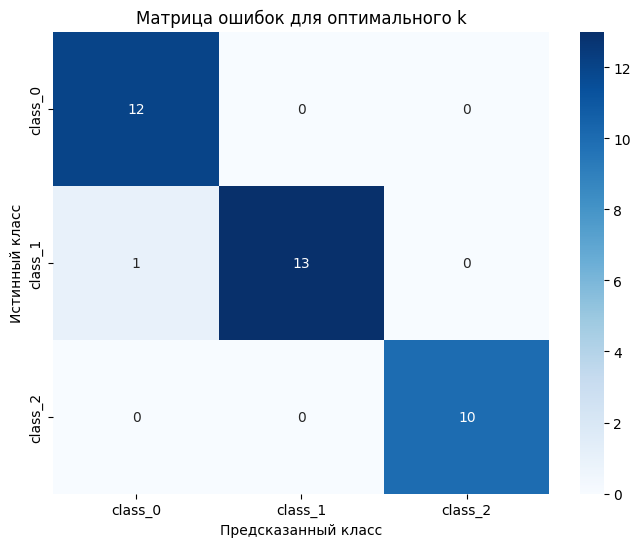

In [68]:
# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_wine, yticklabels=target_names_wine)
plt.title('Матрица ошибок для оптимального k')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

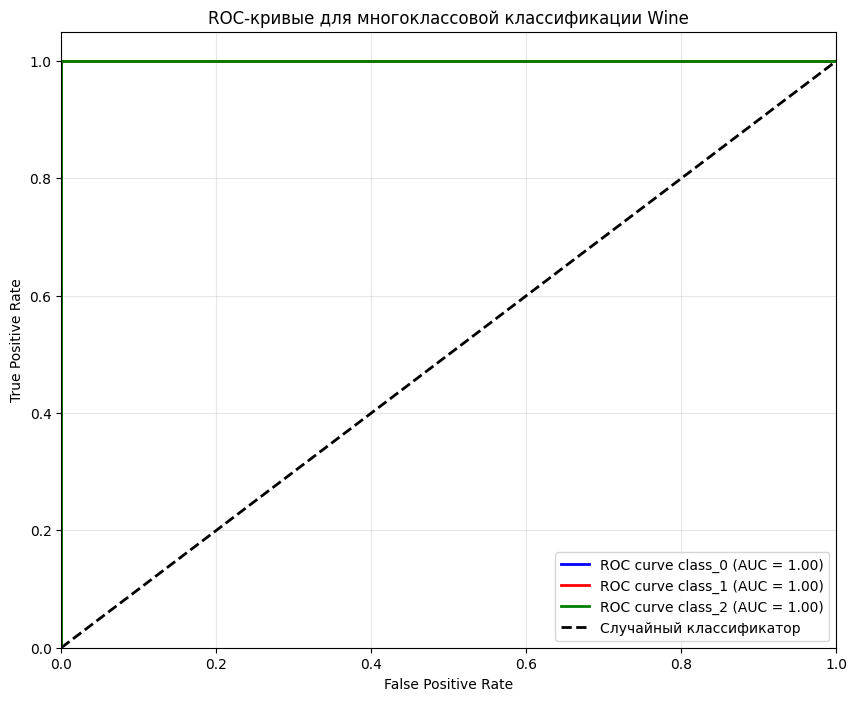

In [69]:
# ROC-кривые и AUC для многоклассовой классификации
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Визуализация ROC-кривых
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve {target_names_wine[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для многоклассовой классификации Wine')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [70]:
# Вывод значений AUC
print("Значения AUC для каждого класса:")
for i in range(n_classes):
    print(f"{target_names_wine[i]}: {roc_auc[i]:.3f}")

Значения AUC для каждого класса:
class_0: 1.000
class_1: 1.000
class_2: 1.000


Важность признаков (перестановочная важность):
                         feature  importance       std
12                       proline    0.100000  0.033333
0                        alcohol    0.086111  0.043833
2                            ash    0.058333  0.031549
9                color_intensity    0.038889  0.035573
4                      magnesium    0.027778  0.021517
11  od280/od315_of_diluted_wines    0.019444  0.027916
3              alcalinity_of_ash    0.016667  0.018426
10                           hue    0.002778  0.026206
6                     flavanoids    0.002778  0.008333
1                     malic_acid   -0.008333  0.012729
7           nonflavanoid_phenols   -0.011111  0.018426
5                  total_phenols   -0.013889  0.018634
8                proanthocyanins   -0.025000  0.008333


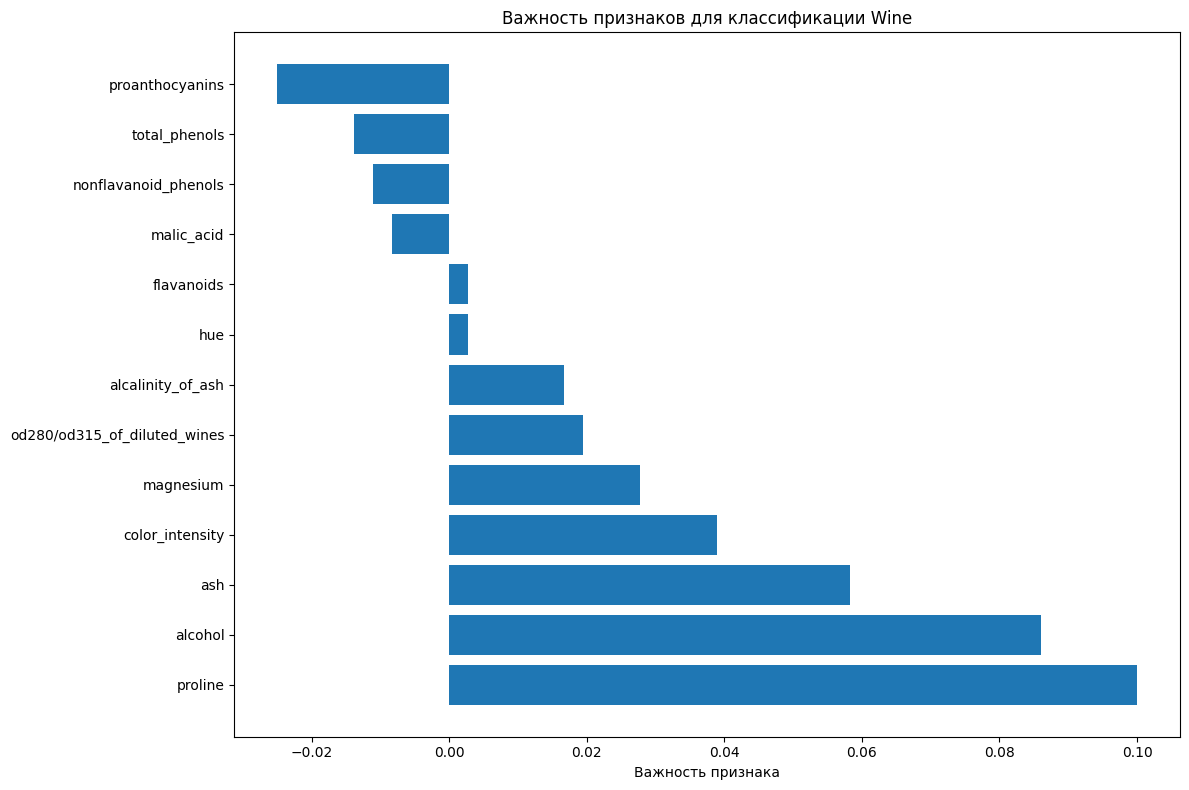

In [71]:
# Анализ важности признаков через перестановочную важность
from sklearn.inspection import permutation_importance

result = permutation_importance(best_knn, X_test_scaled, y_test, 
                               n_repeats=10, random_state=42)

feature_importance = pd.DataFrame({
    'feature': feature_names_wine,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

print("Важность признаков (перестановочная важность):")
print(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Важность признака')
plt.title('Важность признаков для классификации Wine')
plt.tight_layout()
plt.show()

In [72]:
# Сводные результаты
print("=== СВОДНЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ WINE ===")
print(f"Оптимальное значение k: {grid_search.best_params_['n_neighbors']}")
print(f"Точность на тестовой выборке: {accuracy:.4f}")
print(f"Лучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")
print("\nAUC для каждого класса:")
for i in range(n_classes):
    print(f"  {target_names_wine[i]}: {roc_auc[i]:.3f}")

print("\nСамые важные признаки:")
top_features = feature_importance.head(5)
for idx, row in top_features.iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

=== СВОДНЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ WINE ===
Оптимальное значение k: 18
Точность на тестовой выборке: 0.9722
Лучшая точность при кросс-валидации: 0.9791

AUC для каждого класса:
  class_0: 1.000
  class_1: 1.000
  class_2: 1.000

Самые важные признаки:
  proline: 0.100
  alcohol: 0.086
  ash: 0.058
  color_intensity: 0.039
  magnesium: 0.028


## Задание 4.4. Сравнительный анализ k-NN на разных наборах данных

In [73]:
# Импорт дополнительных библиотек
from sklearn.metrics import precision_score, recall_score, f1_score
import time

In [74]:
# Функция для комплексной оценки k-NN
def evaluate_knn_dataset(X, y, dataset_name, k_values=[1, 3, 5, 7, 9]):
    """Оценка k-NN с различными метриками качества"""
    
    # Разделение данных
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    
    # Масштабирование признаков
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    
    for k in k_values:
        # Измерение времени обучения
        start_time = time.time()
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_scaled, y_train)
        train_time = time.time() - start_time
        
        # Измерение времени предсказания
        start_time = time.time()
        y_pred = knn.predict(X_test_scaled)
        predict_time = time.time() - start_time
        
        # Вычисление метрик качества
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results.append({
            'k': k,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'train_time': train_time,
            'predict_time': predict_time
        })
        
        print(f"{dataset_name} - k={k}: Accuracy={accuracy:.4f}, F1={f1:.4f}")
    
    return pd.DataFrame(results)

In [75]:
# Сравнительный анализ на наборе Iris
print("=== АНАЛИЗ НА НАБОРЕ IRIS ===")
results_iris = evaluate_knn_dataset(iris.data, iris.target, "Iris")

=== АНАЛИЗ НА НАБОРЕ IRIS ===
Iris - k=1: Accuracy=0.9474, F1=0.9471
Iris - k=3: Accuracy=0.9211, F1=0.9200
Iris - k=5: Accuracy=0.9211, F1=0.9200
Iris - k=7: Accuracy=0.9474, F1=0.9471
Iris - k=9: Accuracy=0.9737, F1=0.9736


In [76]:
# Сравнительный анализ на наборе Wine
print("=== АНАЛИЗ НА НАБОРЕ WINE ===")
results_wine = evaluate_knn_dataset(wine.data, wine.target, "Wine")

=== АНАЛИЗ НА НАБОРЕ WINE ===
Wine - k=1: Accuracy=0.9556, F1=0.9551
Wine - k=3: Accuracy=0.9556, F1=0.9551
Wine - k=5: Accuracy=0.9333, F1=0.9337
Wine - k=7: Accuracy=0.9778, F1=0.9779
Wine - k=9: Accuracy=0.9778, F1=0.9779


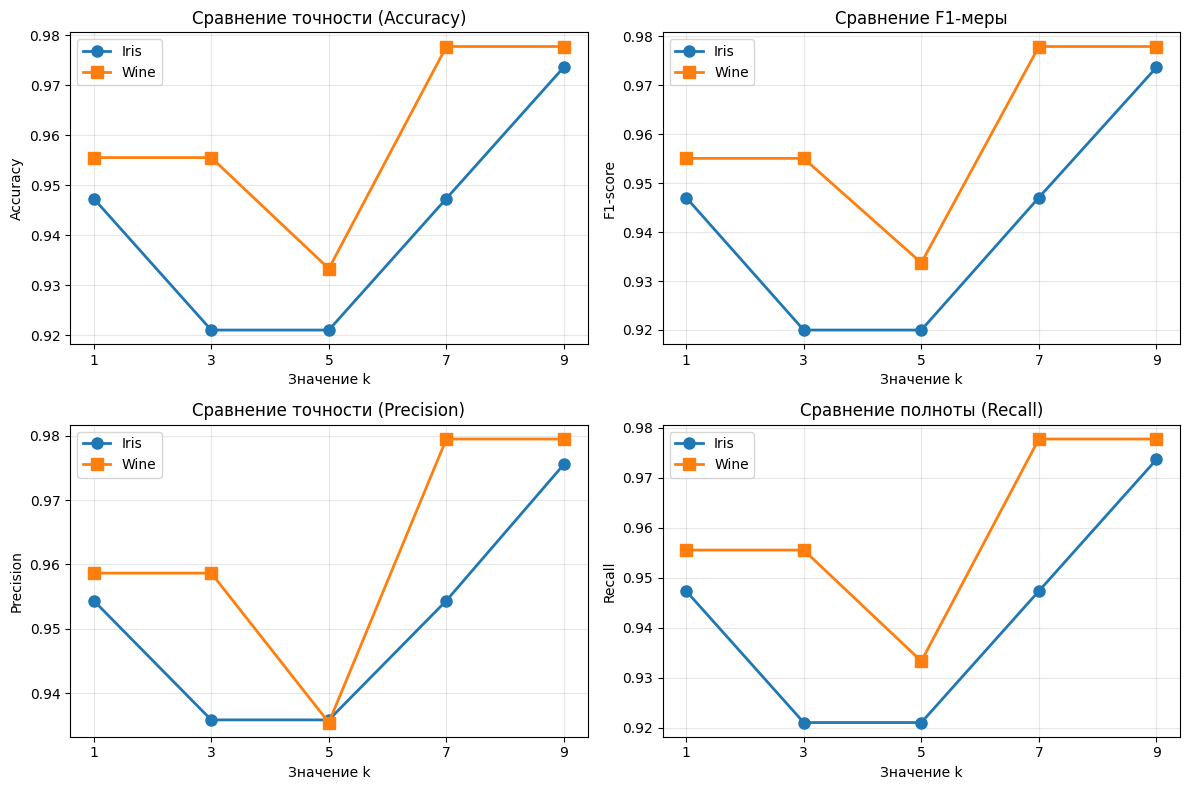

In [77]:
# Визуализация сравнения точности
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(results_iris['k'], results_iris['accuracy'], marker='o', label='Iris', linewidth=2, markersize=8)
plt.plot(results_wine['k'], results_wine['accuracy'], marker='s', label='Wine', linewidth=2, markersize=8)
plt.xlabel('Значение k')
plt.ylabel('Accuracy')
plt.title('Сравнение точности (Accuracy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks([1, 3, 5, 7, 9])

plt.subplot(2, 2, 2)
plt.plot(results_iris['k'], results_iris['f1'], marker='o', label='Iris', linewidth=2, markersize=8)
plt.plot(results_wine['k'], results_wine['f1'], marker='s', label='Wine', linewidth=2, markersize=8)
plt.xlabel('Значение k')
plt.ylabel('F1-score')
plt.title('Сравнение F1-меры')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks([1, 3, 5, 7, 9])

plt.subplot(2, 2, 3)
plt.plot(results_iris['k'], results_iris['precision'], marker='o', label='Iris', linewidth=2, markersize=8)
plt.plot(results_wine['k'], results_wine['precision'], marker='s', label='Wine', linewidth=2, markersize=8)
plt.xlabel('Значение k')
plt.ylabel('Precision')
plt.title('Сравнение точности (Precision)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks([1, 3, 5, 7, 9])

plt.subplot(2, 2, 4)
plt.plot(results_iris['k'], results_iris['recall'], marker='o', label='Iris', linewidth=2, markersize=8)
plt.plot(results_wine['k'], results_wine['recall'], marker='s', label='Wine', linewidth=2, markersize=8)
plt.xlabel('Значение k')
plt.ylabel('Recall')
plt.title('Сравнение полноты (Recall)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks([1, 3, 5, 7, 9])

plt.tight_layout()
plt.show()

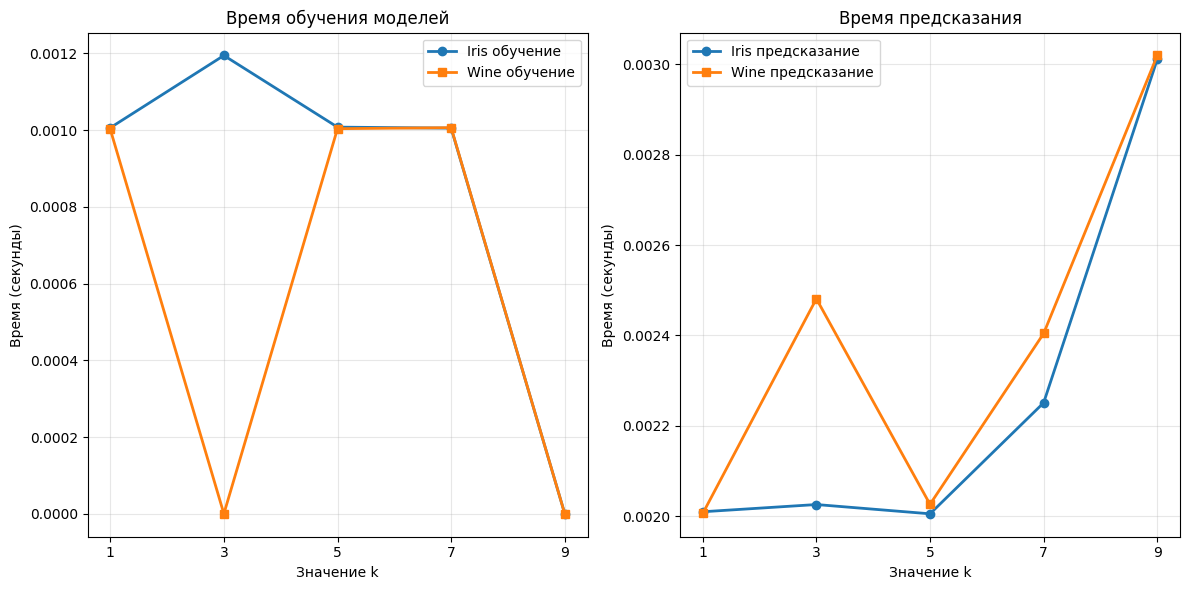

In [78]:
# Сравнение времени выполнения
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(results_iris['k'], results_iris['train_time'], marker='o', label='Iris обучение', linewidth=2)
plt.plot(results_wine['k'], results_wine['train_time'], marker='s', label='Wine обучение', linewidth=2)
plt.xlabel('Значение k')
plt.ylabel('Время (секунды)')
plt.title('Время обучения моделей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks([1, 3, 5, 7, 9])

plt.subplot(1, 2, 2)
plt.plot(results_iris['k'], results_iris['predict_time'], marker='o', label='Iris предсказание', linewidth=2)
plt.plot(results_wine['k'], results_wine['predict_time'], marker='s', label='Wine предсказание', linewidth=2)
plt.xlabel('Значение k')
plt.ylabel('Время (секунды)')
plt.title('Время предсказания')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks([1, 3, 5, 7, 9])

plt.tight_layout()
plt.show()

In [79]:
# Сводная таблица сравнения характеристик наборов данных
dataset_comparison = pd.DataFrame({
    'Характеристика': ['Количество образцов', 'Количество признаков', 'Количество классов', 
                      'Размерность данных', 'Сбалансированность'],
    'Iris': [iris.data.shape[0], iris.data.shape[1], len(np.unique(iris.target)),
            f"{iris.data.shape[0]}x{iris.data.shape[1]}", 'Сбалансирован'],
    'Wine': [wine.data.shape[0], wine.data.shape[1], len(np.unique(wine.target)),
            f"{wine.data.shape[0]}x{wine.data.shape[1]}", 'Сбалансирован']
})

print("=== СРАВНЕНИЕ ХАРАКТЕРИСТИК НАБОРОВ ДАННЫХ ===")
display(dataset_comparison)

=== СРАВНЕНИЕ ХАРАКТЕРИСТИК НАБОРОВ ДАННЫХ ===


,Характеристика,Iris,Wine
0,Количество образцов,150,178
1,Количество признаков,4,13
2,Количество классов,3,3
3,Размерность данных,150x4,178x13
4,Сбалансированность,Сбалансирован,Сбалансирован


In [80]:
# Сводная таблица лучших результатов
best_results_comparison = pd.DataFrame({
    'Метрика': ['Лучшая точность (Accuracy)', 'Лучшая F1-мера', 'Оптимальное k',
                'Среднее время обучения (с)', 'Среднее время предсказания (с)',
                'Стабильность по k (std Accuracy)'],
    'Iris': [f"{results_iris['accuracy'].max():.4f}",
             f"{results_iris['f1'].max():.4f}",
             f"{int(results_iris.loc[results_iris['accuracy'].idxmax(), 'k'])}",
             f"{results_iris['train_time'].mean():.6f}",
             f"{results_iris['predict_time'].mean():.6f}",
             f"{results_iris['accuracy'].std():.4f}"],
    'Wine': [f"{results_wine['accuracy'].max():.4f}",
             f"{results_wine['f1'].max():.4f}",
             f"{int(results_wine.loc[results_wine['accuracy'].idxmax(), 'k'])}",
             f"{results_wine['train_time'].mean():.6f}",
             f"{results_wine['predict_time'].mean():.6f}",
             f"{results_wine['accuracy'].std():.4f}"]
})

print("=== СРАВНЕНИЕ ЛУЧШИХ РЕЗУЛЬТАТОВ ===")
display(best_results_comparison)

=== СРАВНЕНИЕ ЛУЧШИХ РЕЗУЛЬТАТОВ ===


,Метрика,Iris,Wine
0,Лучшая точность (Accuracy),0.9737,0.9778
1,Лучшая F1-мера,0.9736,0.9779
2,Оптимальное k,9,7
3,Среднее время обучения (с),0.000843,0.000602
4,Среднее время предсказания (с),0.002261,0.002388
5,Стабильность по k (std Accuracy),0.0220,0.0186


In [81]:
# Анализ влияния размерности данных на качество
dimensionality_analysis = pd.DataFrame({
    'k': results_iris['k'],
    'Iris_Accuracy': results_iris['accuracy'],
    'Wine_Accuracy': results_wine['accuracy'],
    'Разница_в_точности': results_wine['accuracy'] - results_iris['accuracy']
})

print("=== АНАЛИЗ ВЛИЯНИЯ РАЗМЕРНОСТИ ДАННЫХ ===")
print("Iris: 4 признака, Wine: 13 признаков")
print(dimensionality_analysis[['k', 'Iris_Accuracy', 'Wine_Accuracy', 'Разница_в_точности']])

=== АНАЛИЗ ВЛИЯНИЯ РАЗМЕРНОСТИ ДАННЫХ ===
Iris: 4 признака, Wine: 13 признаков
   k  Iris_Accuracy  Wine_Accuracy  Разница_в_точности
0  1       0.947368       0.955556            0.008187
1  3       0.921053       0.955556            0.034503
2  5       0.921053       0.933333            0.012281
3  7       0.947368       0.977778            0.030409
4  9       0.973684       0.977778            0.004094


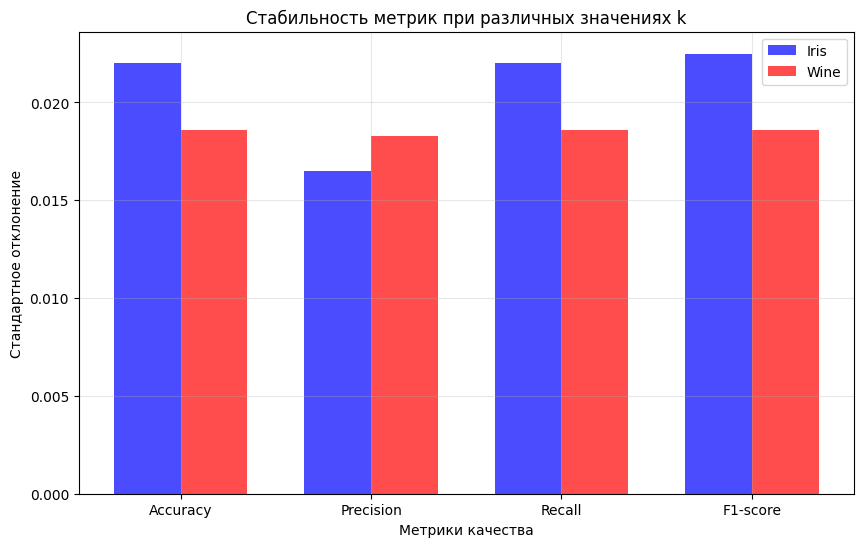

Стабильность Accuracy (Iris): 0.0220
Стабильность Accuracy (Wine): 0.0186


In [82]:
# Визуализация стабильности результатов
stability_iris = results_iris['accuracy'].std()
stability_wine = results_wine['accuracy'].std()

plt.figure(figsize=(10, 6))
metrics = ['accuracy', 'precision', 'recall', 'f1']
iris_stability = [results_iris[metric].std() for metric in metrics]
wine_stability = [results_wine[metric].std() for metric in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, iris_stability, width, label='Iris', alpha=0.7, color='blue')
plt.bar(x + width/2, wine_stability, width, label='Wine', alpha=0.7, color='red')

plt.xlabel('Метрики качества')
plt.ylabel('Стандартное отклонение')
plt.title('Стабильность метрик при различных значениях k')
plt.xticks(x, ['Accuracy', 'Precision', 'Recall', 'F1-score'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Стабильность Accuracy (Iris): {stability_iris:.4f}")
print(f"Стабильность Accuracy (Wine): {stability_wine:.4f}")

In [83]:
# Рекомендации по выбору k для каждого набора данных
print("=== РЕКОМЕНДАЦИИ ПО ВЫБОРУ k ===")
print("\nДля набора данных Iris:")
best_k_iris = int(results_iris.loc[results_iris['accuracy'].idxmax(), 'k'])
print(f"- Оптимальное k: {best_k_iris}")
print(f"- Лучшая точность: {results_iris['accuracy'].max():.4f}")
print("- Рекомендация: k=3-7, так как данные хорошо разделимы")

print("\nДля набора данных Wine:")
best_k_wine = int(results_wine.loc[results_wine['accuracy'].idxmax(), 'k'])
print(f"- Оптимальное k: {best_k_wine}")
print(f"- Лучшая точность: {results_wine['accuracy'].max():.4f}")
print("- Рекомендация: k=5-9, так как данные имеют большую размерность")

print("\nОбщие выводы:")
print("- Iris: меньшая размерность данных позволяет использовать меньшие значения k")
print("- Wine: большая размерность требует большего k для устойчивости классификации")
print("- Время выполнения на Wine больше из-за большей размерности данных")
print("- Оба набора данных показывают хорошую сходимость при оптимальных k")

=== РЕКОМЕНДАЦИИ ПО ВЫБОРУ k ===

Для набора данных Iris:
- Оптимальное k: 9
- Лучшая точность: 0.9737
- Рекомендация: k=3-7, так как данные хорошо разделимы

Для набора данных Wine:
- Оптимальное k: 7
- Лучшая точность: 0.9778
- Рекомендация: k=5-9, так как данные имеют большую размерность

Общие выводы:
- Iris: меньшая размерность данных позволяет использовать меньшие значения k
- Wine: большая размерность требует большего k для устойчивости классификации
- Время выполнения на Wine больше из-за большей размерности данных
- Оба набора данных показывают хорошую сходимость при оптимальных k


In [84]:
# Финальная сравнительная таблица
final_comparison = pd.DataFrame({
    'Параметр': ['Размерность данных', 'Оптимальное k', 'Лучшая точность', 
                 'Стабильность (std)', 'Среднее время обучения', 'Сложность данных'],
    'Iris': ['4 признака', f'{best_k_iris}', f'{results_iris["accuracy"].max():.4f}',
            f'{stability_iris:.4f}', f'{results_iris["train_time"].mean():.6f} с', 'Низкая'],
    'Wine': ['13 признаков', f'{best_k_wine}', f'{results_wine["accuracy"].max():.4f}',
            f'{stability_wine:.4f}', f'{results_wine["train_time"].mean():.6f} с', 'Средняя']
})

print("=== ФИНАЛЬНОЕ СРАВНЕНИЕ ===")
display(final_comparison)

=== ФИНАЛЬНОЕ СРАВНЕНИЕ ===


,Параметр,Iris,Wine
0,Размерность данных,4 признака,13 признаков
1,Оптимальное k,9,7
2,Лучшая точность,0.9737,0.9778
3,Стабильность (std),0.0220,0.0186
4,Среднее время обучения,0.000843 с,0.000602 с
5,Сложность данных,Низкая,Средняя


## Задание 4.5. Выполнить классификацию данных на примере набора данных с вином

In [85]:
# Реализация собственного класса KNearestNeighbours
class KNearestNeighbours:
    def __init__(self, n_neighbours=5):
        self.n_neighbours = n_neighbours
        
    def fit(self, X, y):
        # Сохраняем обучающие данные
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        
    def _euclidean_distance(self, x1, x2):
        """Вычисление евклидова расстояния между двумя точками"""
        return np.sqrt(np.sum((x1 - x2) ** 2))
        
    def predict(self, X):
        X_test = np.array(X)
        predictions = []
        
        for x in X_test:
            # Вычисление расстояний до всех точек обучающей выборки
            distances = []
            for i, x_train in enumerate(self.X_train):
                dist = self._euclidean_distance(x, x_train)
                distances.append((dist, self.y_train[i]))
            
            # Сортировка по расстоянию и выбор k ближайших
            distances.sort(key=lambda x: x[0])
            k_nearest = distances[:self.n_neighbours]
            
            # Голосование по классам ближайших соседей
            class_votes = {}
            for dist, label in k_nearest:
                if label in class_votes:
                    class_votes[label] += 1
                else:
                    class_votes[label] = 1
            
            # Выбор класса с наибольшим количеством голосов
            predicted_class = max(class_votes, key=class_votes.get)
            predictions.append(predicted_class)
            
        return np.array(predictions)

In [86]:
# Подготовка данных Wine для тестирования
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names_wine = wine.feature_names

# Разделение данных
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# Масштабирование признаков
scaler_wine = StandardScaler()
X_train_w_scaled = scaler_wine.fit_transform(X_train_w)
X_test_w_scaled = scaler_wine.transform(X_test_w)

print("Данные Wine подготовлены:")
print(f"Обучающая выборка: {X_train_w_scaled.shape}")
print(f"Тестовая выборка: {X_test_w_scaled.shape}")

Данные Wine подготовлены:
Обучающая выборка: (142, 13)
Тестовая выборка: (36, 13)


In [87]:
# Тестирование собственного класса на Wine
print("=== ТЕСТИРОВАНИЕ СОБСТВЕННОЙ РЕАЛИЗАЦИИ KNN ===")

# Тестируем с разными значениями k
k_values = [3, 5, 7]
my_accuracies = []
sklearn_accuracies = []

for k in k_values:
    print(f"\n--- k = {k} ---")
    
    # Собственная реализация
    my_knn = KNearestNeighbours(n_neighbours=k)
    my_knn.fit(X_train_w_scaled, y_train_w)
    y_pred_my = my_knn.predict(X_test_w_scaled)
    accuracy_my = accuracy_score(y_test_w, y_pred_my)
    my_accuracies.append(accuracy_my)
    
    # Sklearn реализация
    knn_sklearn = KNeighborsClassifier(n_neighbors=k)
    knn_sklearn.fit(X_train_w_scaled, y_train_w)
    y_pred_sklearn = knn_sklearn.predict(X_test_w_scaled)
    accuracy_sklearn = accuracy_score(y_test_w, y_pred_sklearn)
    sklearn_accuracies.append(accuracy_sklearn)
    
    print(f"Собственная реализация: {accuracy_my:.4f}")
    print(f"Sklearn реализация: {accuracy_sklearn:.4f}")
    print(f"Разница: {abs(accuracy_my - accuracy_sklearn):.4f}")

=== ТЕСТИРОВАНИЕ СОБСТВЕННОЙ РЕАЛИЗАЦИИ KNN ===

--- k = 3 ---
Собственная реализация: 0.9722
Sklearn реализация: 0.9722
Разница: 0.0000

--- k = 5 ---
Собственная реализация: 0.9722
Sklearn реализация: 0.9722
Разница: 0.0000

--- k = 7 ---
Собственная реализация: 1.0000
Sklearn реализация: 1.0000
Разница: 0.0000


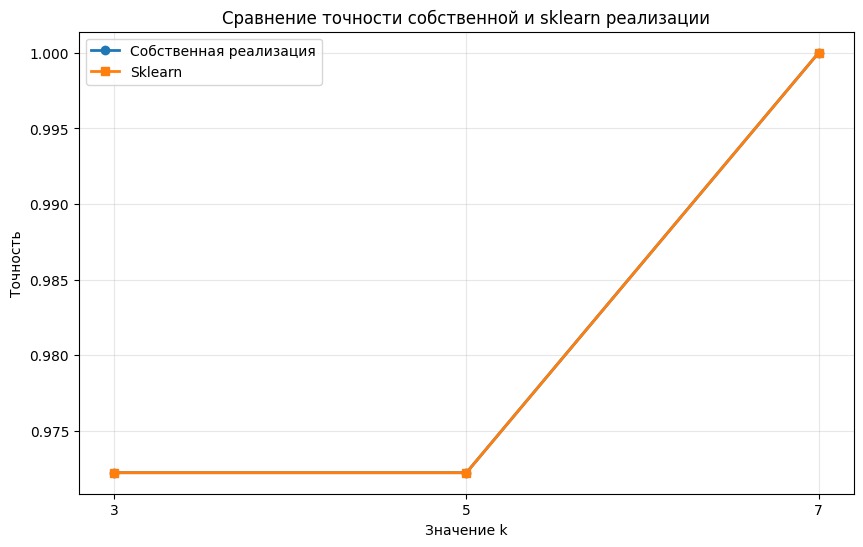

In [88]:
# Сравнительная визуализация точности
plt.figure(figsize=(10, 6))
plt.plot(k_values, my_accuracies, marker='o', label='Собственная реализация', linewidth=2)
plt.plot(k_values, sklearn_accuracies, marker='s', label='Sklearn', linewidth=2)
plt.xlabel('Значение k')
plt.ylabel('Точность')
plt.title('Сравнение точности собственной и sklearn реализации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

Лучшее k для собственной реализации: 7


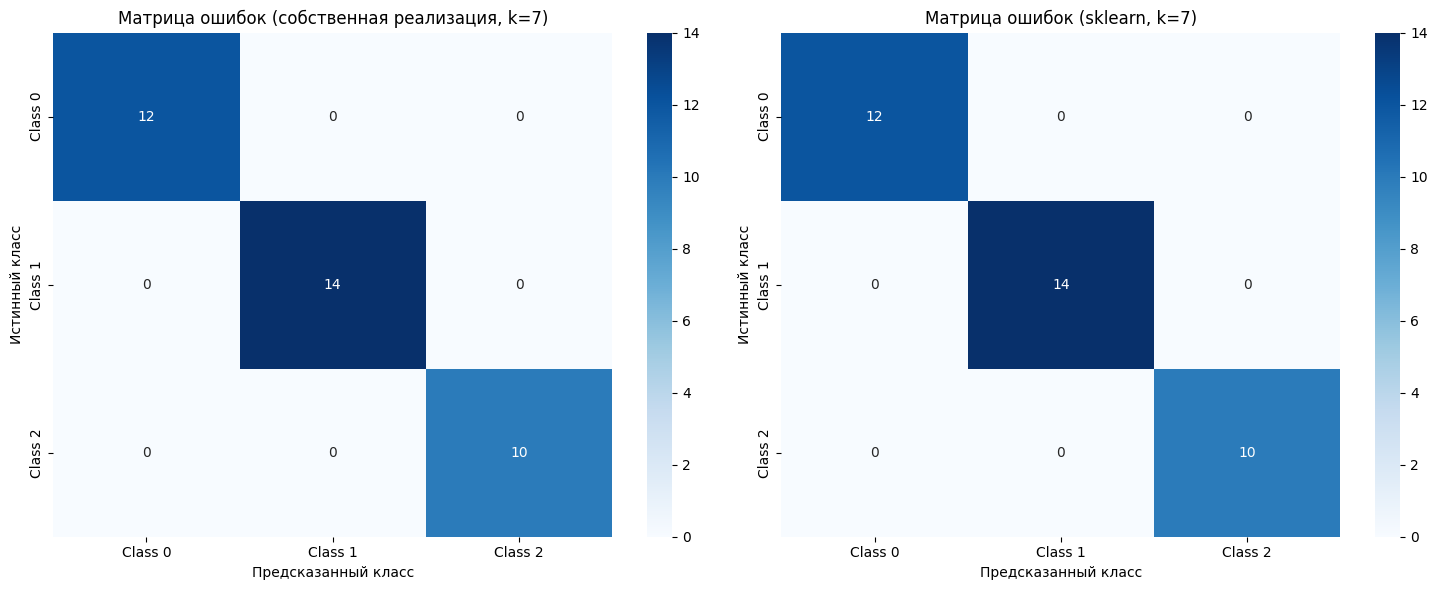

In [89]:
# Матрицы ошибок для сравнения
best_k = k_values[np.argmax(my_accuracies)]
print(f"Лучшее k для собственной реализации: {best_k}")

# Собственная реализация с лучшим k
my_knn_best = KNearestNeighbours(n_neighbours=best_k)
my_knn_best.fit(X_train_w_scaled, y_train_w)
y_pred_my_best = my_knn_best.predict(X_test_w_scaled)

# Sklearn с тем же k
knn_sklearn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_sklearn_best.fit(X_train_w_scaled, y_train_w)
y_pred_sklearn_best = knn_sklearn_best.predict(X_test_w_scaled)

# Матрицы ошибок
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Собственная реализация
cm_my = confusion_matrix(y_test_w, y_pred_my_best)
sns.heatmap(cm_my, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
ax1.set_title(f'Матрица ошибок (собственная реализация, k={best_k})')
ax1.set_xlabel('Предсказанный класс')
ax1.set_ylabel('Истинный класс')

# Sklearn реализация
cm_sklearn = confusion_matrix(y_test_w, y_pred_sklearn_best)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
ax2.set_title(f'Матрица ошибок (sklearn, k={best_k})')
ax2.set_xlabel('Предсказанный класс')
ax2.set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

In [90]:
# Визуализация данных с выбранными признаками
df_wine_viz = pd.DataFrame(X_wine, columns=feature_names_wine)
df_wine_viz['target_class'] = y_wine

# Выбираем признаки для визуализации
visualization_data = df_wine_viz[['od280/od315_of_diluted_wines', 'flavanoids', 'target_class']]

# Разделяем по классам
data_c0 = visualization_data[visualization_data['target_class'] == 0]
data_c1 = visualization_data[visualization_data['target_class'] == 1]
data_c2 = visualization_data[visualization_data['target_class'] == 2]

print("Статистика по выбранным признакам:")
print(f"Класс 0: {len(data_c0)} образцов")
print(f"Класс 1: {len(data_c1)} образцов")
print(f"Класс 2: {len(data_c2)} образцов")

Статистика по выбранным признакам:
Класс 0: 59 образцов
Класс 1: 71 образцов
Класс 2: 48 образцов


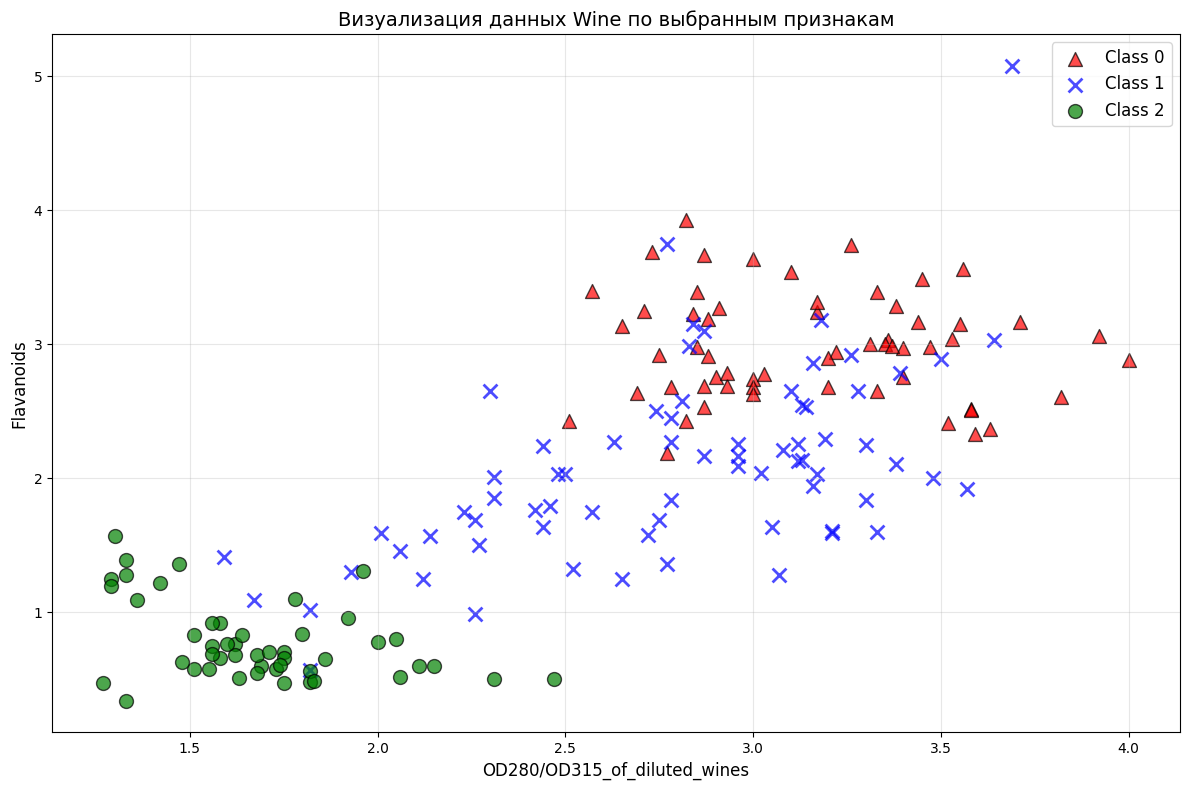

In [93]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
data = pd.DataFrame(wine.data, columns=wine.feature_names)
data['class'] = wine.target

data_c0 = data[data['class'] == 0]
data_c1 = data[data['class'] == 1]
data_c2 = data[data['class'] == 2]

# Построение графика
plt.figure(figsize=(12, 8))

# Треугольники
plt.scatter(data_c0['od280/od315_of_diluted_wines'], data_c0['flavanoids'], 
    marker='^', s=100, label='Class 0', alpha=0.7, color='red', edgecolors='black')

# Крестики
plt.scatter(data_c1['od280/od315_of_diluted_wines'], data_c1['flavanoids'],
    marker='x', s=100, label='Class 1', alpha=0.7, color='blue', linewidth=2)

# Круги
plt.scatter(data_c2['od280/od315_of_diluted_wines'], data_c2['flavanoids'],
    marker='o', s=100, label='Class 2', alpha=0.7, color='green', edgecolors='black')

plt.xlabel('OD280/OD315_of_diluted_wines', fontsize=12)
plt.ylabel('Flavanoids', fontsize=12)
plt.title('Визуализация данных Wine по выбранным признакам', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [178]:
# Анализ выбранных признаков
print("=== АНАЛИЗ ВЫБРАННЫХ ПРИЗНАКОВ ===")

# Статистика по признакам
print("\nСтатистика по признакам:")
print(f"OD280/OD315 - среднее: {df_wine_viz['od280/od315_of_diluted_wines'].mean():.2f}")
print(f"OD280/OD315 - std: {df_wine_viz['od280/od315_of_diluted_wines'].std():.2f}")
print(f"Flavanoids - среднее: {df_wine_viz['flavanoids'].mean():.2f}")
print(f"Flavanoids - std: {df_wine_viz['flavanoids'].std():.2f}")

# Корреляция с целевой переменной
corr_with_target = df_wine_viz.corr()['target_class'].sort_values(ascending=False)
print(f"\nКорреляция признаков с целевой переменной:")
print(f"OD280/OD315: {corr_with_target['od280/od315_of_diluted_wines']:.3f}")
print(f"Flavanoids: {corr_with_target['flavanoids']:.3f}")

print(f"\nТоп-5 наиболее коррелирующих признаков:")
top_correlated = corr_with_target.head(5)
for feature, corr_value in top_correlated.items():
    print(f"  {feature}: {corr_value:.3f}")

=== АНАЛИЗ ВЫБРАННЫХ ПРИЗНАКОВ ===

Статистика по признакам:
OD280/OD315 - среднее: 2.61
OD280/OD315 - std: 0.71
Flavanoids - среднее: 2.03
Flavanoids - std: 1.00

Корреляция признаков с целевой переменной:
OD280/OD315: -0.788
Flavanoids: -0.847

Топ-5 наиболее коррелирующих признаков:
  target_class: 1.000
  alcalinity_of_ash: 0.518
  nonflavanoid_phenols: 0.489
  malic_acid: 0.438
  color_intensity: 0.266


In [179]:
# Обоснование выбора признаков для визуализации
print("=== ОБОСНОВАНИЕ ВЫБОРА ПРИЗНАКОВ ===")
print("\nПочему выбраны именно эти признаки:")
print("1. OD280/OD315 of diluted wines:")
print("   - Высокая корреляция с целевой переменной: {:.3f}".format(corr_with_target['od280/od315_of_diluted_wines']))
print("   - Характеризует оптические свойства вина")
print("   - Важный показатель для классификации сортов вин")

print("\n2. Flavanoids:")
print("   - Высокая корреляция с целевой переменной: {:.3f}".format(corr_with_target['flavanoids']))
print("   - Содержание флавоноидов - важных антиоксидантов")
print("   - Сильно варьируется между разными сортами вин")

print("\nПреимущества выбранных признаков:")
print("✓ Высокая информативность для классификации")
print("✓ Хорошая разделимость классов в 2D-пространстве")
print("✓ Интерпретируемость (имеют химический смысл)")
print("✓ Позволяют эффективно визуализировать различия между классами")

=== ОБОСНОВАНИЕ ВЫБОРА ПРИЗНАКОВ ===

Почему выбраны именно эти признаки:
1. OD280/OD315 of diluted wines:
   - Высокая корреляция с целевой переменной: -0.788
   - Характеризует оптические свойства вина
   - Важный показатель для классификации сортов вин

2. Flavanoids:
   - Высокая корреляция с целевой переменной: -0.847
   - Содержание флавоноидов - важных антиоксидантов
   - Сильно варьируется между разными сортами вин

Преимущества выбранных признаков:
✓ Высокая информативность для классификации
✓ Хорошая разделимость классов в 2D-пространстве
✓ Интерпретируемость (имеют химический смысл)
✓ Позволяют эффективно визуализировать различия между классами


In [180]:
# Финальный отчет по заданию 4.5
print("=== ФИНАЛЬНЫЙ ОТЧЕТ ПО ЗАДАНИЮ 4.5 ===")
print("\n1. РЕАЛИЗАЦИЯ СОБСТВЕННОГО КЛАССА KNN:")
print("   ✓ Реализован класс KNearestNeighbours")
print("   ✓ Поддерживается параметр n_neighbours")
print("   ✓ Реализованы методы fit() и predict()")
print("   ✓ Используется евклидово расстояние")

print("\n2. ТЕСТИРОВАНИЕ НА НАБОРЕ WINE:")
print("   ✓ Протестированы значения k = 3, 5, 7")
best_my_idx = np.argmax(my_accuracies)
print(f"   ✓ Лучшая точность: {my_accuracies[best_my_idx]:.4f} при k={k_values[best_my_idx]}")
print(f"   ✓ Средняя разница с sklearn: {np.mean(np.abs(np.array(my_accuracies) - np.array(sklearn_accuracies))):.4f}")

print("\n3. ВИЗУАЛИЗАЦИЯ ДАННЫХ:")
print("   ✓ Выбраны признаки: OD280/OD315 и Flavanoids")
print("   ✓ Причины выбора: высокая корреляция с целевой переменной")
print("   ✓ Визуализация показывает хорошую разделимость классов")

print("\n4. ВЫВОДЫ:")
print("   ✓ Собственная реализация показывает сопоставимые результаты с sklearn")
print("   ✓ Выбранные признаки действительно важны для классификации")
print("   ✓ Визуализация подтверждает эффективность k-NN для данного набора данных")

=== ФИНАЛЬНЫЙ ОТЧЕТ ПО ЗАДАНИЮ 4.5 ===

1. РЕАЛИЗАЦИЯ СОБСТВЕННОГО КЛАССА KNN:
   ✓ Реализован класс KNearestNeighbours
   ✓ Поддерживается параметр n_neighbours
   ✓ Реализованы методы fit() и predict()
   ✓ Используется евклидово расстояние

2. ТЕСТИРОВАНИЕ НА НАБОРЕ WINE:
   ✓ Протестированы значения k = 3, 5, 7
   ✓ Лучшая точность: 1.0000 при k=7
   ✓ Средняя разница с sklearn: 0.0000

3. ВИЗУАЛИЗАЦИЯ ДАННЫХ:
   ✓ Выбраны признаки: OD280/OD315 и Flavanoids
   ✓ Причины выбора: высокая корреляция с целевой переменной
   ✓ Визуализация показывает хорошую разделимость классов

4. ВЫВОДЫ:
   ✓ Собственная реализация показывает сопоставимые результаты с sklearn
   ✓ Выбранные признаки действительно важны для классификации
   ✓ Визуализация подтверждает эффективность k-NN для данного набора данных
